# Лабораторная №1, курс ASR

## Импорты и константы

In [53]:
from IPython.display import Image, display
from pprint import pp

import librosa
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
import pandas as pd
from pathlib import Path

In [27]:
AUDIO_DIR = Path("data/wav")

CLEAN_PATH = AUDIO_DIR / "clean_speech_like.wav"
NOISY_PATH = AUDIO_DIR / "noisy_speech_like.wav"
REVERBERANT_PATH = AUDIO_DIR / "reverberant_speech_like.wav"
CLIPPED_PATH = AUDIO_DIR / "clipped_speech_like.wav"
PERTURBED_PATH = AUDIO_DIR / "speed_perturbed_speech_like.wav"

In [28]:
SR = librosa.get_samplerate(CLEAN_PATH)

In [29]:
OUTPUTS_DIR = Path("outputs")

In [30]:
AUDIO_DICT = {
    "Чистый": CLEAN_PATH, 
    "Зашумленный": NOISY_PATH, 
    "С ревербом": REVERBERANT_PATH, 
    "С клиппингом": CLIPPED_PATH, 
    "С изменением в скорости": PERTURBED_PATH
}

## Часть А

**Вопросы:**

1. У какого файла, по вашему ожиданию, будет самая высокая RMS-энергия?

Ожидается, что выше всего RMS будет у зашумленного сигнала `noisy_speech_like.wav`, потому что к сигналу появляется широкополосный шум и увеличивает энергию даже на тех участках, где в оригинальном сигнале была тишина

1. В каком файле, по вашему ожиданию, искажение волновой формы будет наиболее заметным?

В `clipped_speech_like.wav`. Клиппинг и есть искажение звуковой волны, которое обрезает аудиопоследовательность на одном и том же уровне y.

2. В каком файле, по вашему ожиданию, спектральные переходы будут наиболее размытыми?

Предполагаю, что в `reverberant_speech_like.wav`. Реверб как раз оставляет хвост эхо от предыдущего звука, так что это даст "размытый" спектральный переход

*Проверим это*

### Волна

In [31]:
MAX_Y_REF_PONT = 1.0

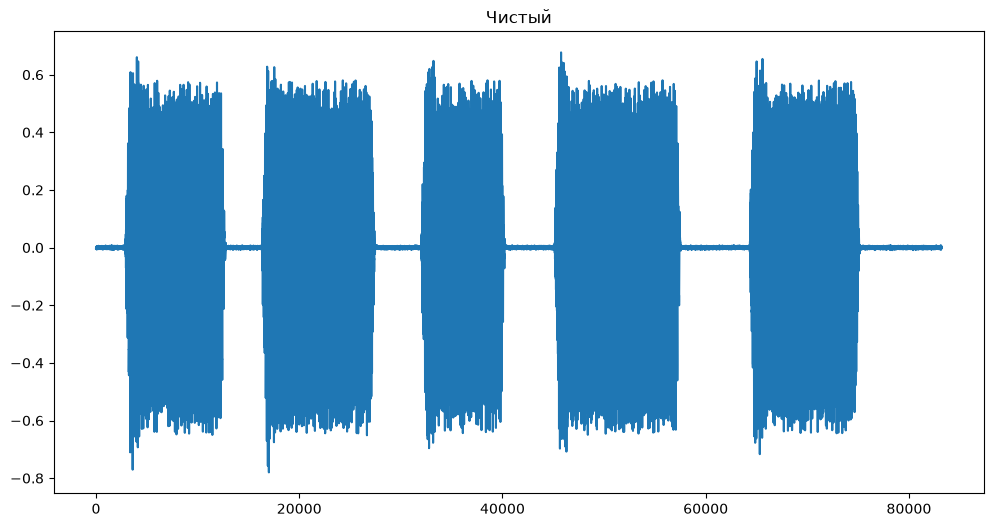

In [32]:
clean, _ = librosa.load(CLEAN_PATH, sr=SR)

plt.figure(figsize=(12, 6))
plt.plot(clean)
plt.title("Чистый")
plt.show()

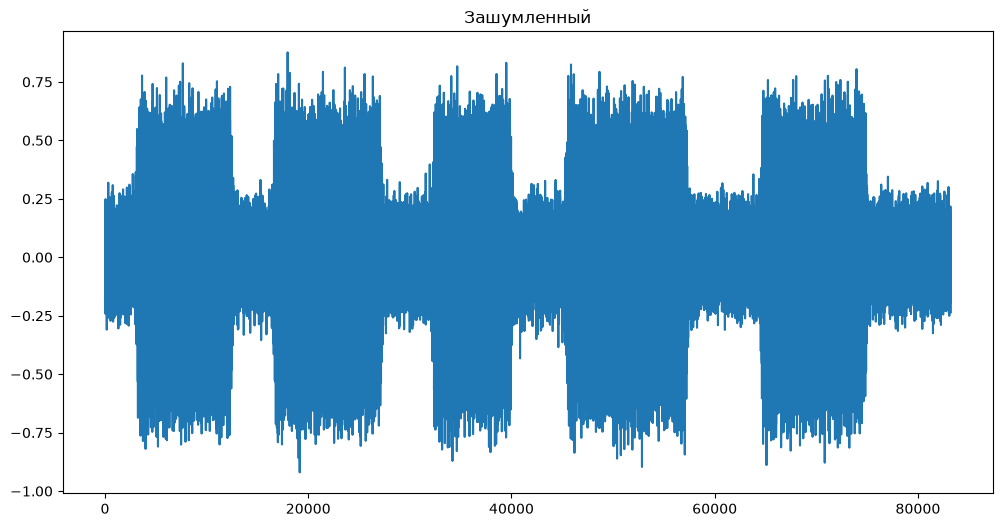

In [33]:
noisy, _ = librosa.load(NOISY_PATH, sr=SR)

plt.figure(figsize=(12, 6))
plt.plot(noisy)
plt.title("Зашумленный")
plt.show()

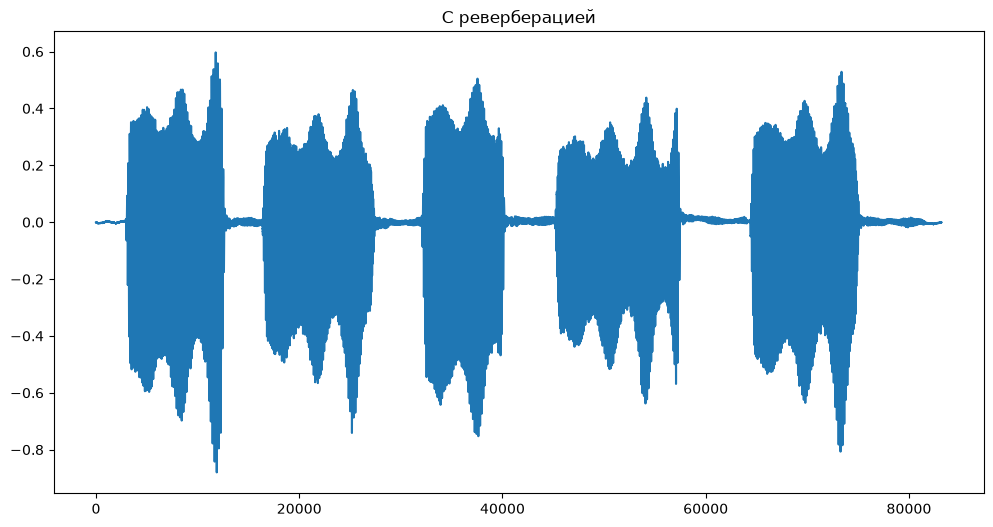

In [34]:
reverberant, _ = librosa.load(REVERBERANT_PATH, sr=SR)

plt.figure(figsize=(12, 6))
plt.plot(reverberant)
plt.title("С реверберацией")
plt.show()

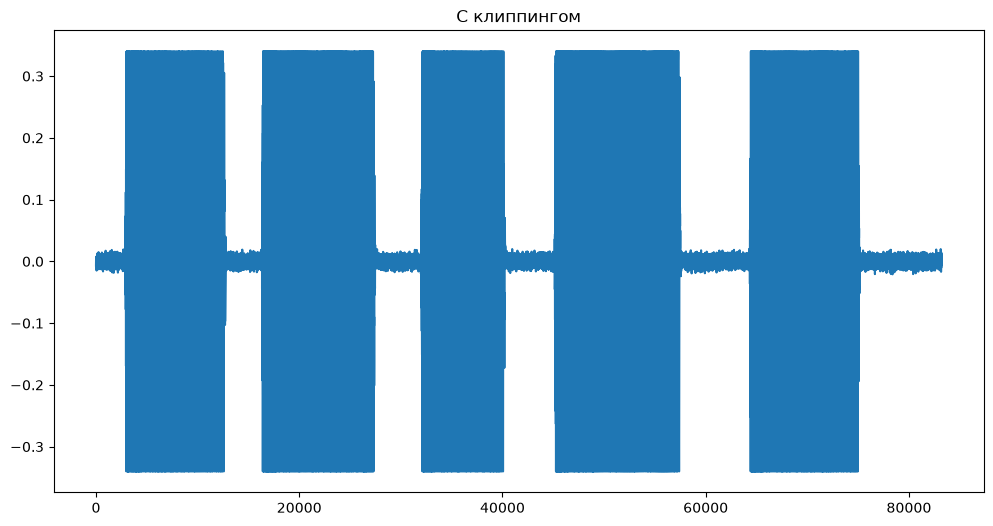

In [35]:
clipped, _ = librosa.load(CLIPPED_PATH, sr=SR)

plt.figure(figsize=(12, 6))
plt.plot(clipped)
plt.title("С клиппингом")
plt.show()

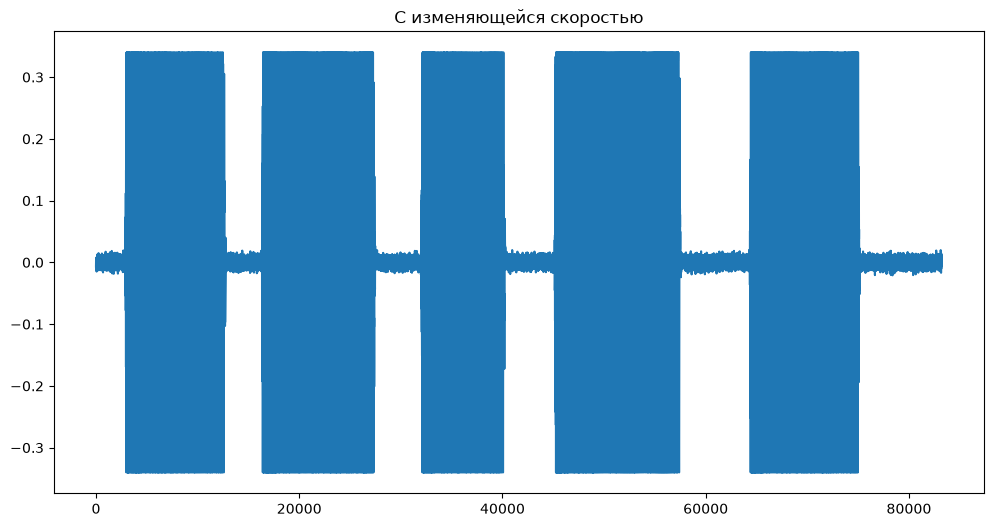

In [36]:
perturbed, _ = librosa.load(PERTURBED_PATH, sr=SR)

plt.figure(figsize=(12, 6))
plt.plot(clipped)
plt.title("С изменяющейся скоростью")
plt.show()

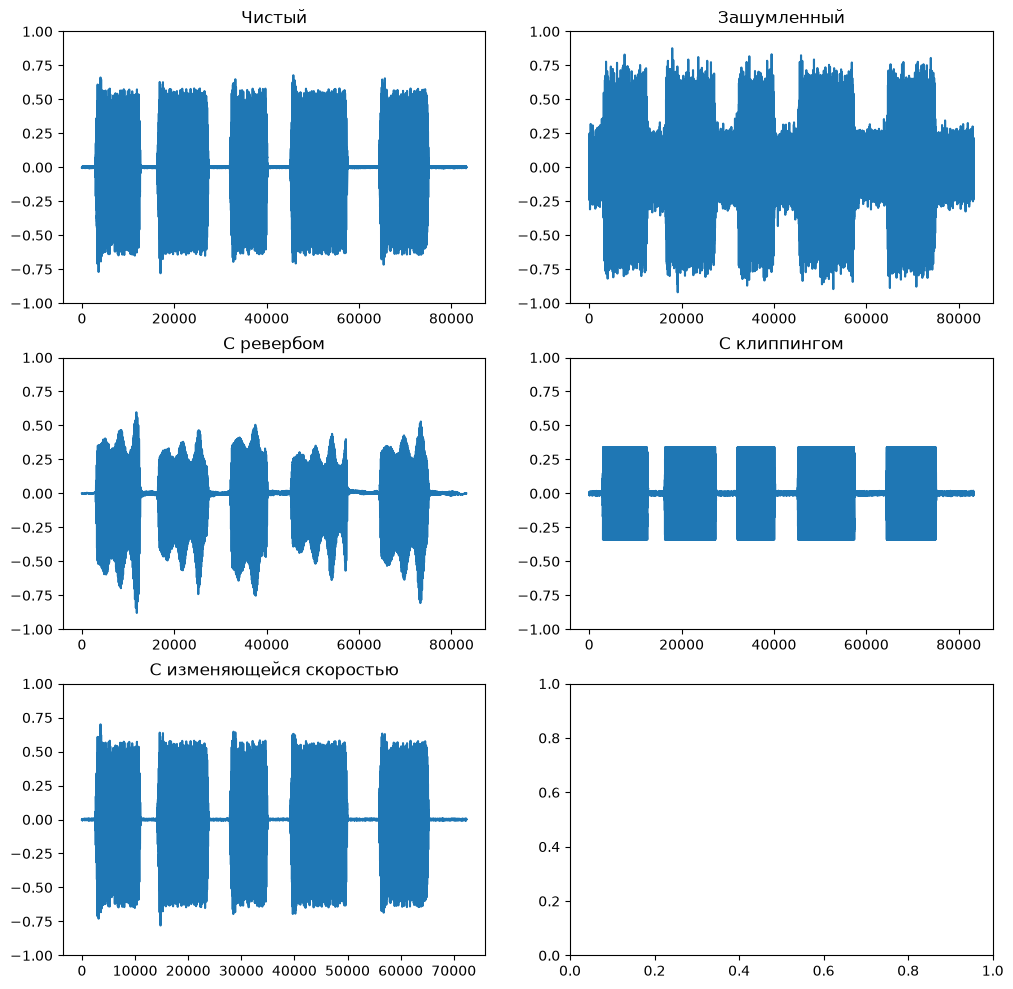

In [37]:
fig, ax = plt.subplots(3, 2, figsize=(12, 12))

ax[0,0].plot(clean)
ax[0,0].set_ylim(-1.0, 1.0)
ax[0,0].set_title("Чистый")

ax[0,1].plot(noisy)
ax[0,1].set_ylim(-1.0, 1.0)
ax[0,1].set_title("Зашумленный")

ax[1,0].plot(reverberant)
ax[1,0].set_ylim(-1.0, 1.0)
ax[1,0].set_title("С ревербом")

ax[1,1].plot(clipped)
ax[1,1].set_ylim(-1.0, 1.0)
ax[1,1].set_title("С клиппингом")

ax[2,0].plot(perturbed)
ax[2,0].set_ylim(-1.0, 1.0)
ax[2,0].set_title("С изменяющейся скоростью")

plt.show()

Конечно, тут чуть субъективно определение того, какое "искажение волновой формы будет наиболее заметным", потому что зашумленный сигнал тоже довольно сильно искажен. Но все-таки и в этом, и в общем случае, моя оценка – клиппинг сильнее всего искажает сигнал

Подтвердили ответ на первый вопрос

### RMS

In [38]:
rms = {
    audio: librosa.feature.rms(
        y=librosa.load(AUDIO_DICT[audio], sr=SR)[0]
    ).mean()
    for audio in AUDIO_DICT
}

pp(rms)
print()
# Было просто ругательство от линтера про .get(), что он может возвращать None
# Отсюда лямбда
print(f"Максимальный RMS у: {max(rms, key=lambda x: rms[x])}")

{'Чистый': np.float32(0.20674379),
 'Зашумленный': np.float32(0.24317038),
 'С ревербом': np.float32(0.17688267),
 'С клиппингом': np.float32(0.20546484),
 'С изменением в скорости': np.float32(0.20842107)}

Максимальный RMS у: Зашумленный


Подтвердили первый ответ на вопрос

### Спектральные переходы

/Users/ivanguseff/VScode/ASR_course_labs/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1811: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ivanguseff/VScode/ASR_course_labs/.venv/lib/python3.14/site-packages/matplotlib/transforms.py:2914: ComplexWarning: Casting complex values to real discards the imaginary part
  vmin, vmax = map(float, [vmin, vmax])


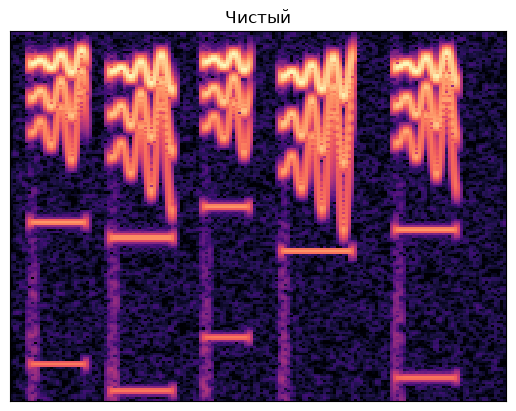

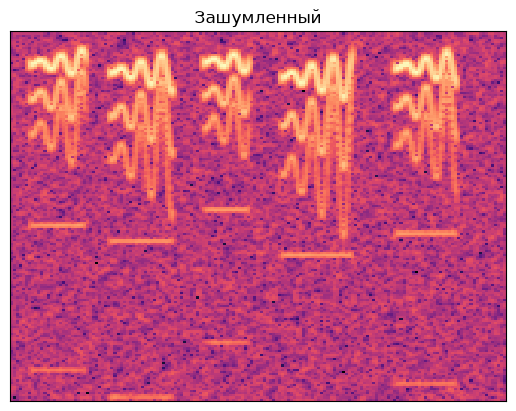

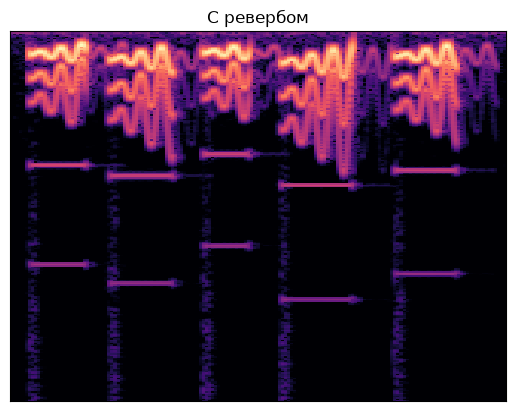

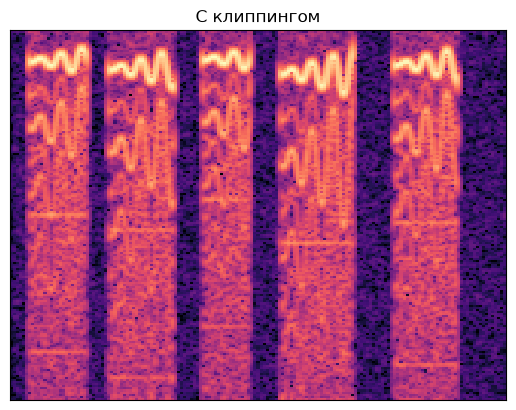

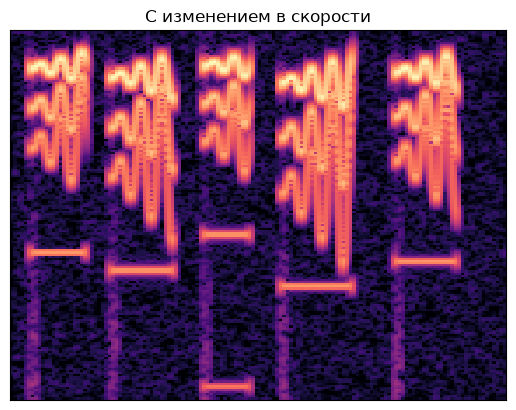

In [39]:
def get_spec(audio_path, title):
    y, _ = librosa.load(audio_path, sr=SR)

    D = librosa.stft(y)
    plt.ylim(np.max(D))
    librosa.display.specshow(D, sr=SR, hop_length=1024,
                        vscale='dBFS')
    plt.title(title)
    plt.show()

for audio in AUDIO_DICT:
    get_spec(AUDIO_DICT[audio], audio)

С реверберацией спектр действительно становится самым размытым в переходах. Еще сюда можно добавить клиппинг как претендента на второе мето. Видимо, из-за клиппинга в сигнале появился алиасинг и частоты, которые были клиппированы пошли инвертированно спектру

Подтвердили ответ на третий вопрос

## Часть B

In [40]:
def get_stats(audio_path):
    y, sr = librosa.load(audio_path, sr=SR)

    duration = len(y) / sr

    peak_amp = np.max(np.abs(y))

    rms = librosa.feature.rms(y=y).mean()

    sil_threshold = 0.1
    silence_fraction = np.mean(np.abs(y) < sil_threshold)

    abs_y = np.abs(y)
    # Берём только верхние 10% по амплитуде
    high = abs_y[abs_y >= np.quantile(abs_y, 0.9)]
    # Округляем, чтобы очень близкие значения считались одним уровнем
    rounded = np.round(high, 3)
    values, counts = np.unique(rounded, return_counts=True)
    # Самый часто встречающийся уровень среди больших амплитуд
    threshold = values[np.argmax(counts)]
    # Доля отсчётов около этого уровня
    clipping_fraction = np.mean(
        np.isclose(abs_y, threshold, atol=1e-3)
    )

    return [
        duration,
        peak_amp,
        rms,
        silence_fraction,
        clipping_fraction
    ]

In [41]:
stats_list = []
for audio in AUDIO_DICT:
    stats_list.append([audio] + get_stats(AUDIO_DICT[audio]))
# get_stats(CLIPPED_PATH)

stats_cols = [
    "Файл",
    "Длительность",
    "Пиковая амплитуда",
    "RMS",
    "Доля тишины",
    "Доля клиппинга"
]

stats_df = pd.DataFrame(
    data=stats_list,
    columns=stats_cols,
).set_index("Файл")

In [42]:
print(stats_df)

                         Длительность  Пиковая амплитуда       RMS  \
Файл                                                                 
Чистый                        5.20000           0.780029  0.206744   
Зашумленный                   5.20000           0.920013  0.243170   
С ревербом                    5.20000           0.880005  0.176883   
С клиппингом                  5.20000           0.340027  0.205465   
С изменением в скорости       4.52175           0.780029  0.208421   

                         Доля тишины  Доля клиппинга  
Файл                                                  
Чистый                      0.485024        0.002055  
Зашумленный                 0.379880        0.001707  
С ревербом                  0.510877        0.001923  
С клиппингом                0.418534        0.460853  
С изменением в скорости     0.484754        0.002059  


**Вопросы:**

1. У какого файла доля клиппинга ненулевая или необычно высокая? Почему?
2. У какого файла самая короткая длительность? Почему?
3. Почему доля тишины может быть важна для ASR на длинных записях?

1. У файла с клиппингом. Потому что в других файлах клиппинга нет
2. Самая короткая длительность у файла с изменением в скорости. Файл ускоряется -> длина уменьшается
3. Можно просто убрать тишину и не тратить вычислительные мощности на нее. В ASR-системах трансформерах тишина/шум превращается в галлюцианции

## Часть C

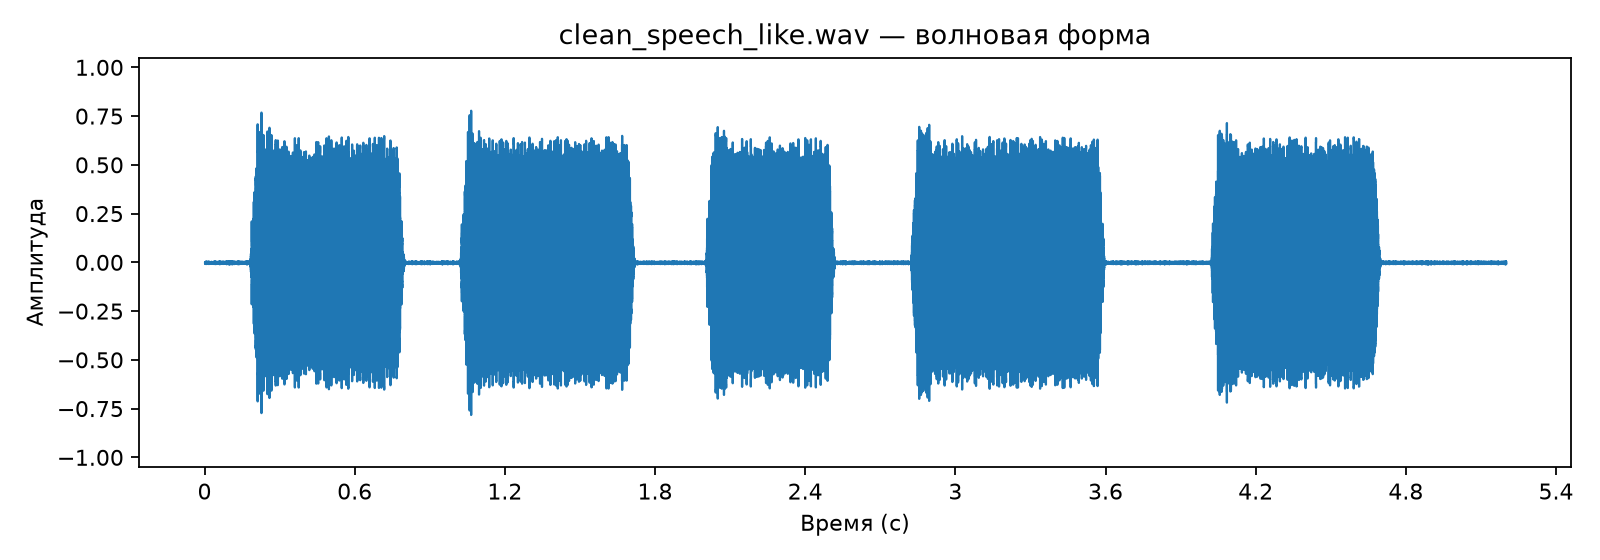

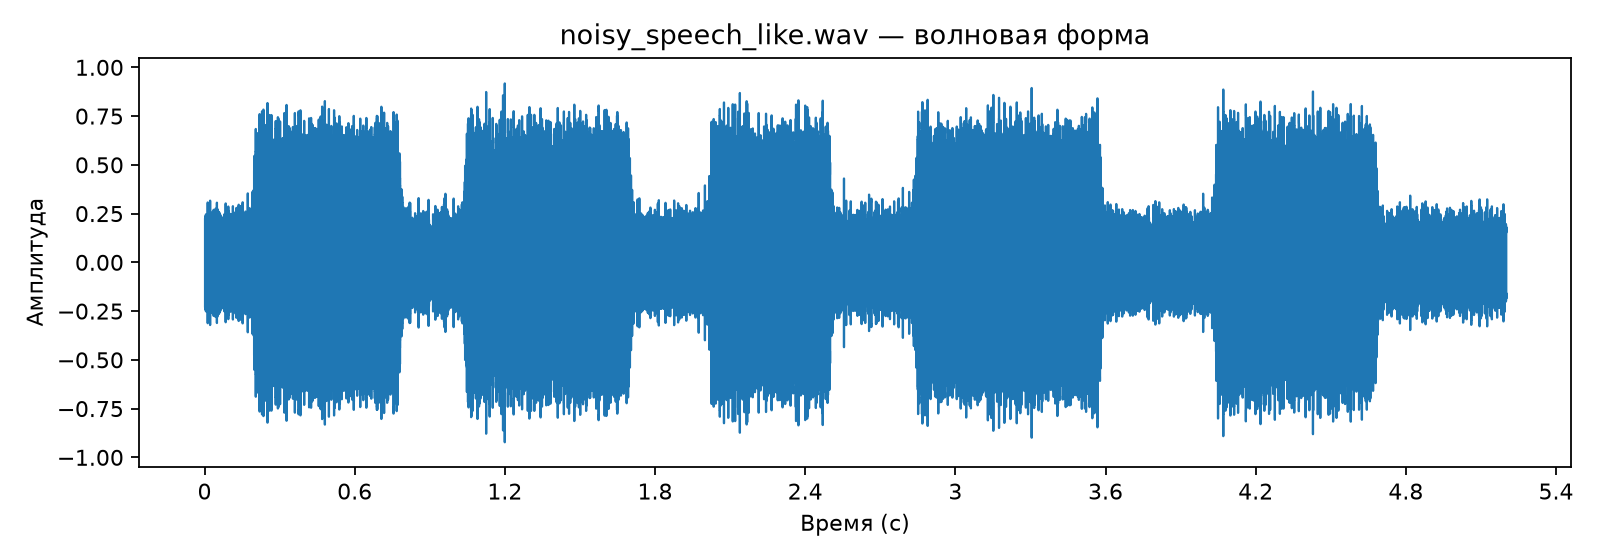

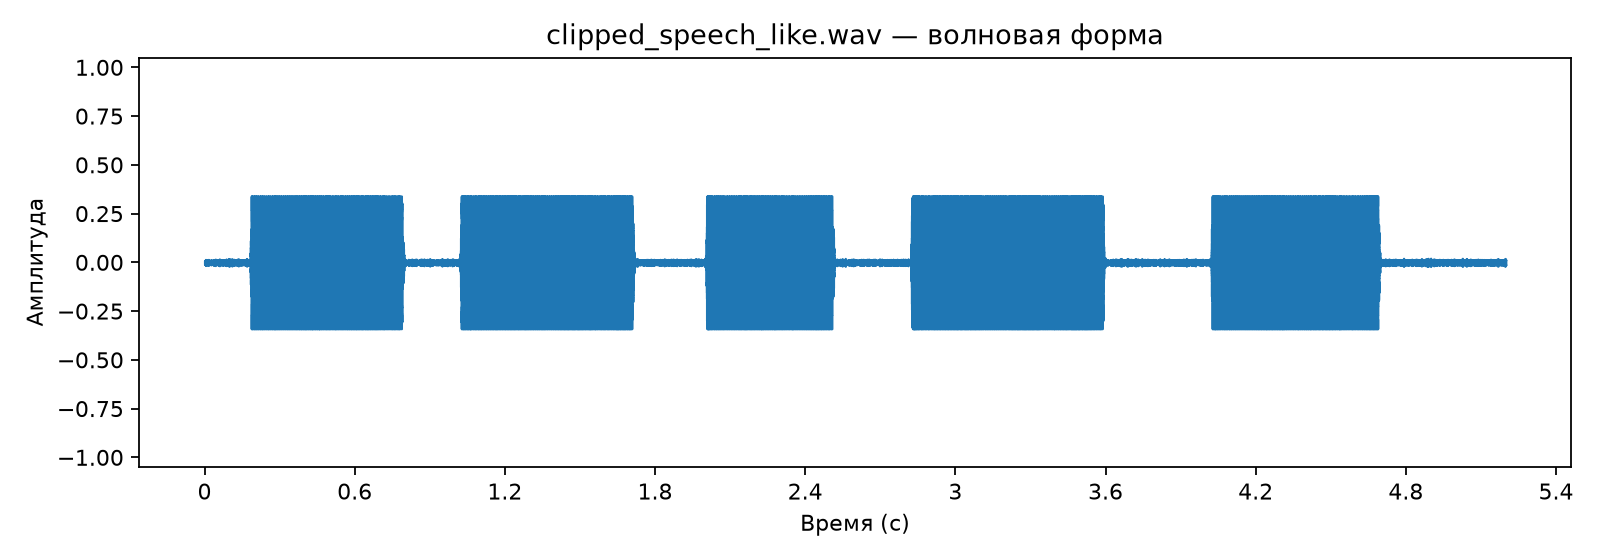

Zoomed


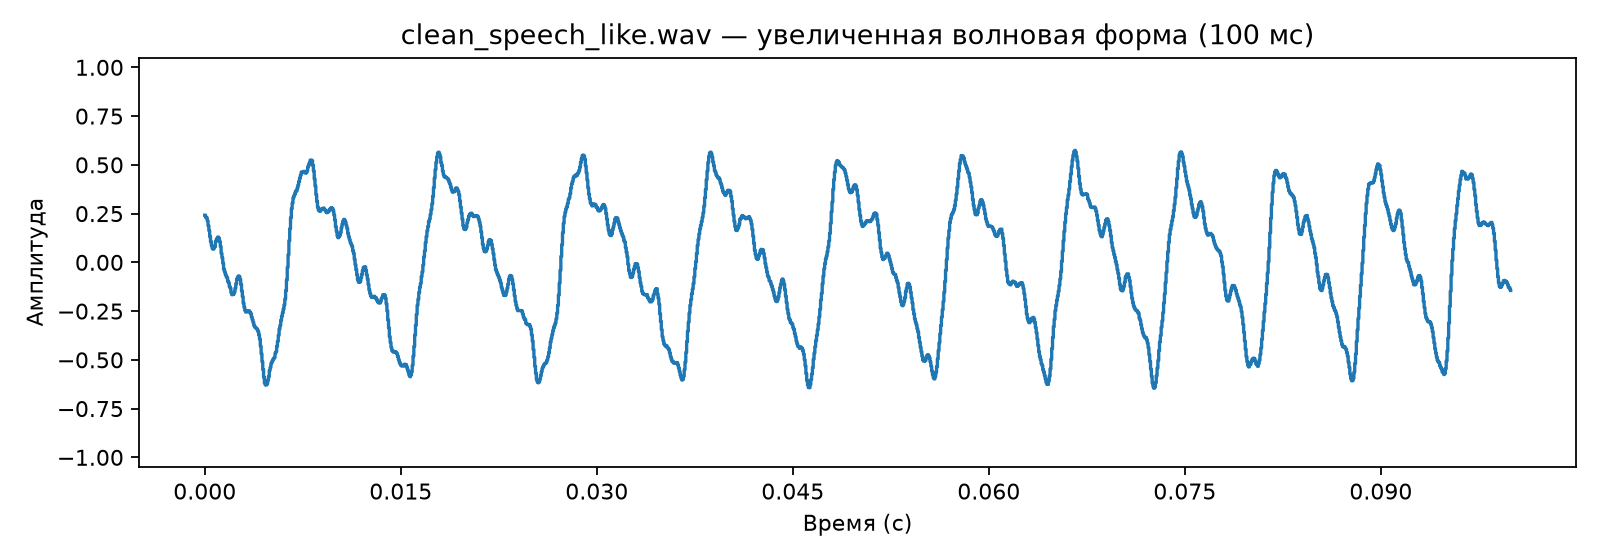

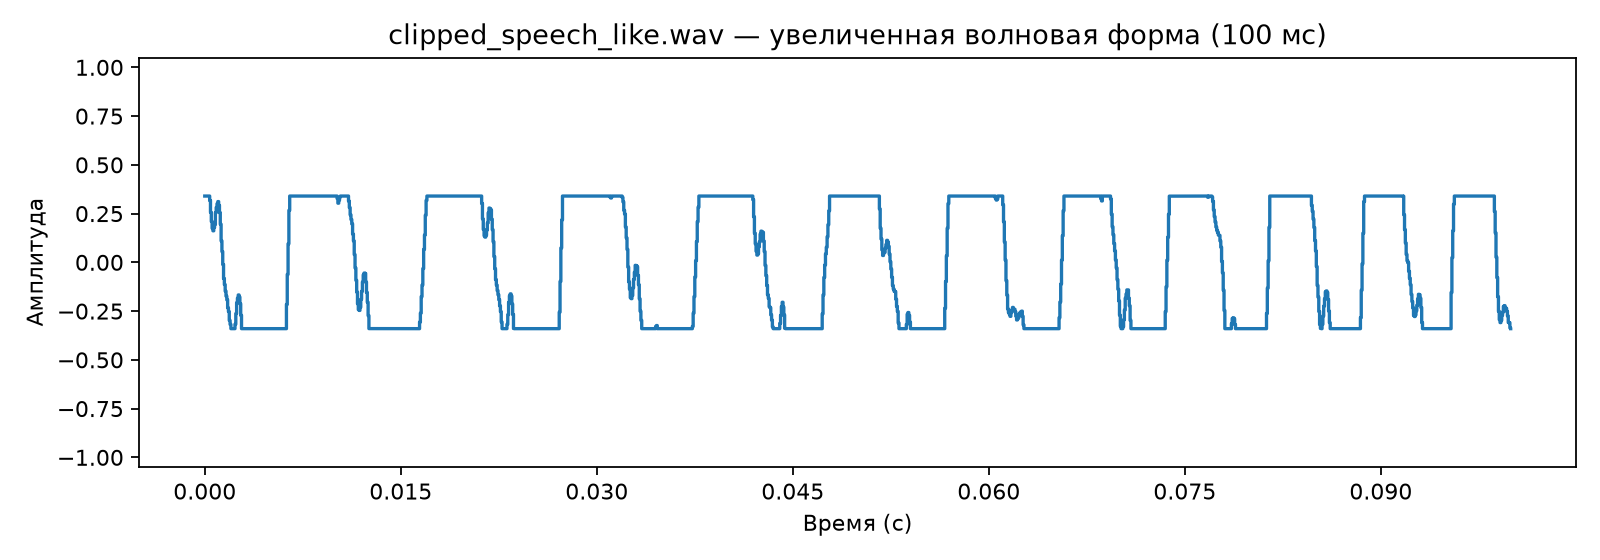

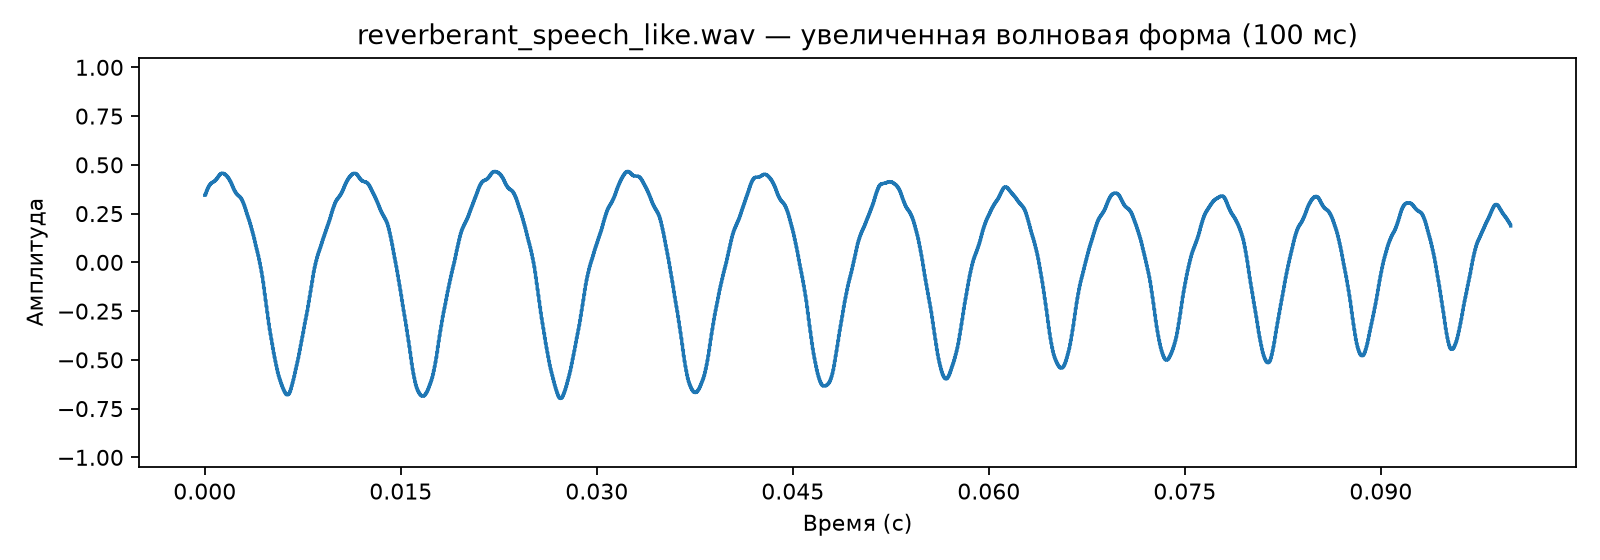

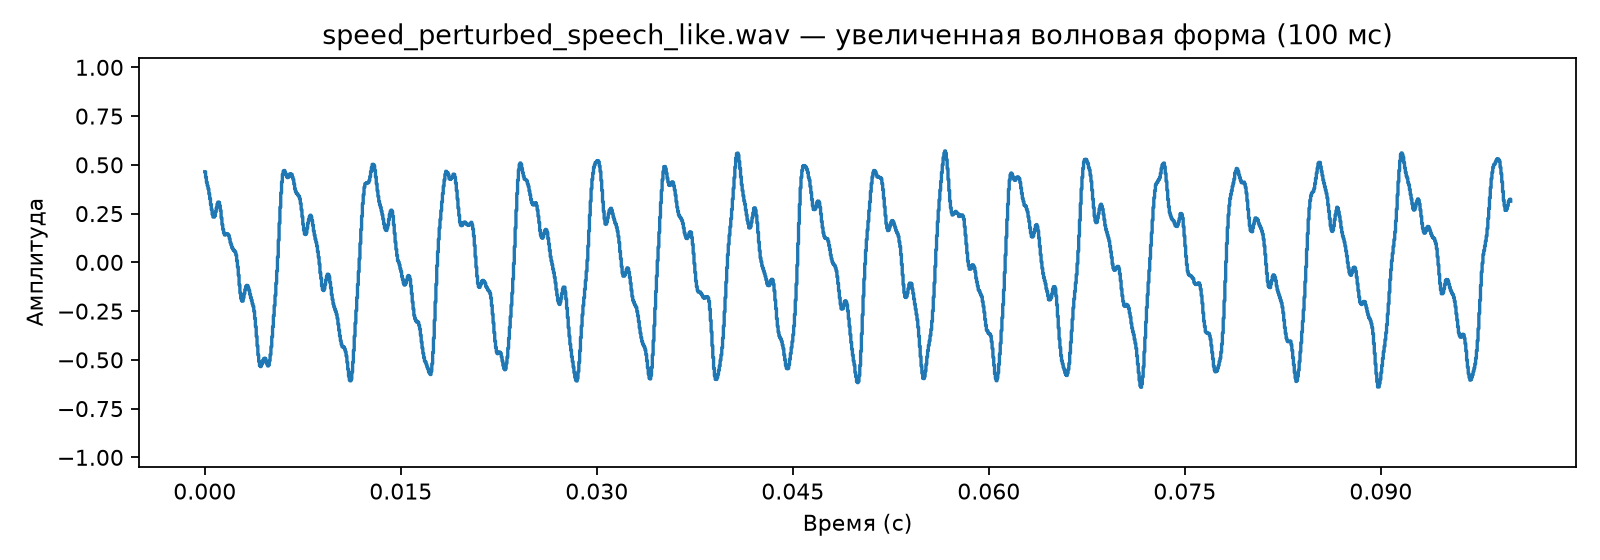

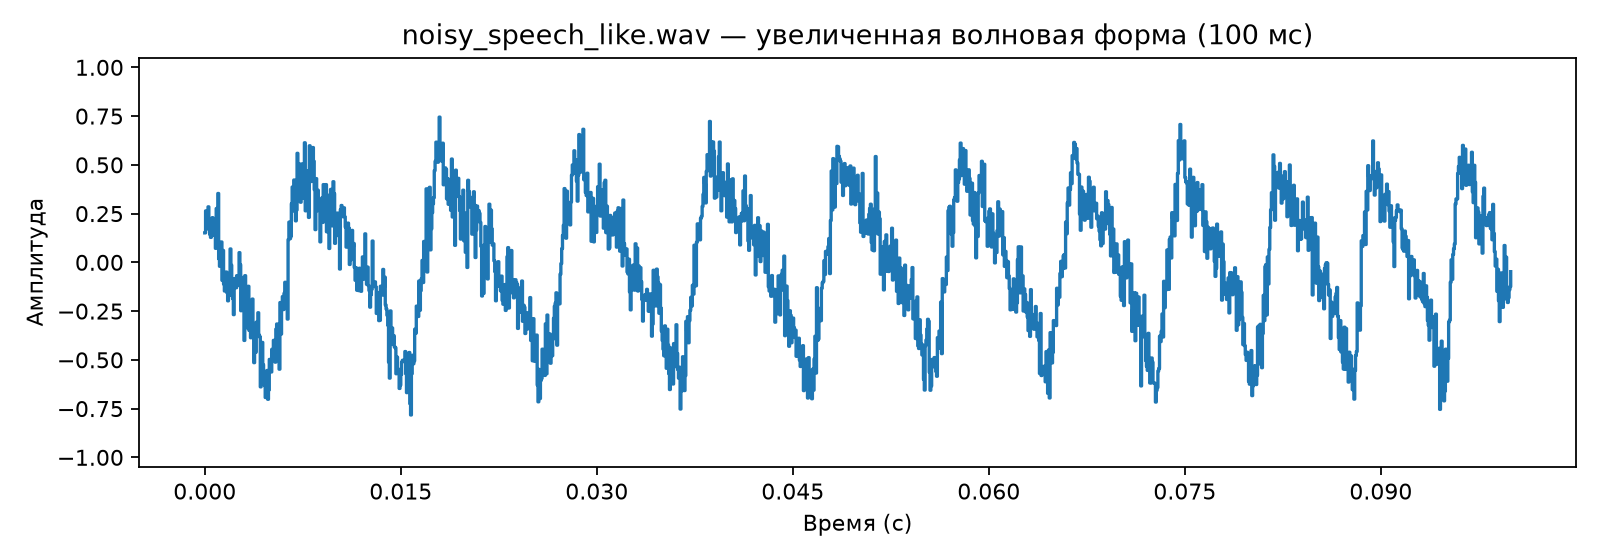

In [43]:
display(Image(filename=OUTPUTS_DIR / "clean_speech_like_waveform.png"))
display(Image(filename=OUTPUTS_DIR / "noisy_speech_like_waveform.png"))
display(Image(filename=OUTPUTS_DIR / "clipped_speech_like_waveform.png"))
print("Zoomed")
zoomed_waveforms = OUTPUTS_DIR.glob("*_waveform_zoom.png")
for waveform in zoomed_waveforms:
    display(Image(filename=waveform))

**Вопросы:**

1. Какое искажение легче всего увидеть на волновой форме?
2. Как выглядит клиппинг?
3. Почему одной амплитуды может быть недостаточно, чтобы понять содержание речи?

1. Зашумленность быстрее всего бросается в глаза
2. Клиппинг переводится как обрезка. Конечно, понятие глубже и проникает не только в речевые технологии, но даже в соседние сферы. Есть soft clipping и hard clipping. Hard clipping просто обрезает все, что выше (по модулю) порогового значения, это выглядит как плато на осциллограмме. Soft clipping – чем ближе к пределу сигнал, тем он сильнее сжимается. То есть, это не плато, а постепенное сглаживание
3. Часто можно понять примерно что произносится на записи только по осциллограмме: тут качество зависит от насмотренности на осциллограммы человека. Примерно можно понять структуру фразы: где-то смычка, где-то шумный, где-то сонорный, звонкий/гласный и так далее. Но вот например гласные определить только по осциллограмме крайне трудно, потому что они все от чисто голосового источника без примесей и на графике выглядят как периодические колебания. Тут нужен спектр и форманты. В целом, со спектром содержание речи становится более понятным. Видны формантные переходы, лучше различимыми становятся звонкость/глухость.

## Часть D

In [44]:
spec_imgs = list(OUTPUTS_DIR.glob("*_stft_spectrogram.png"))

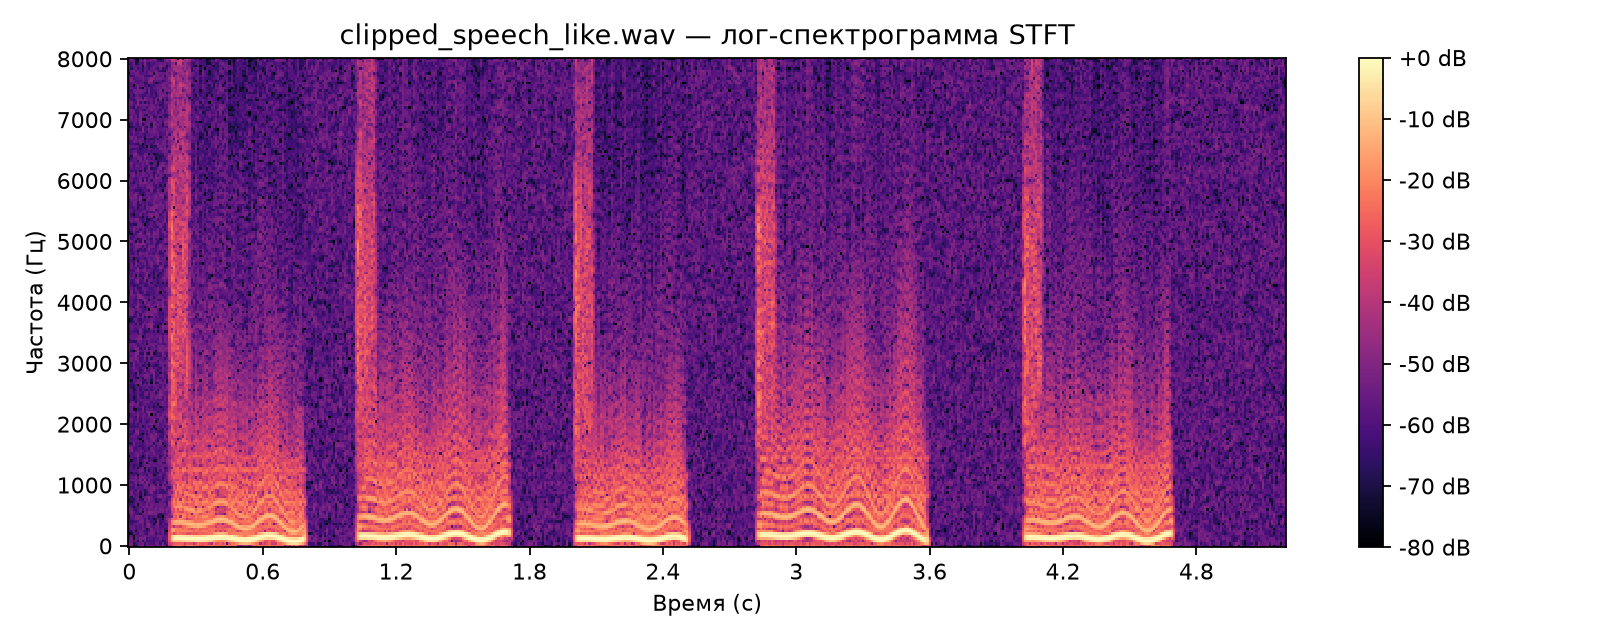

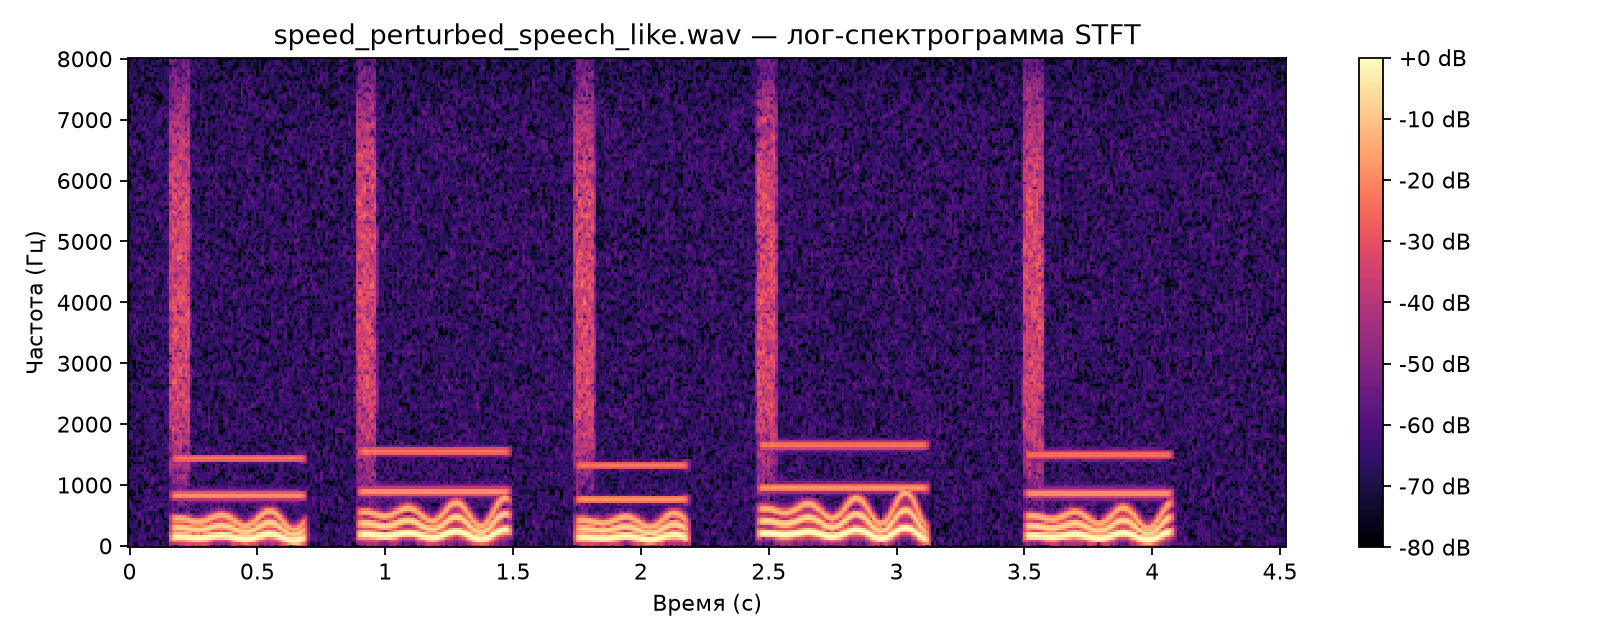

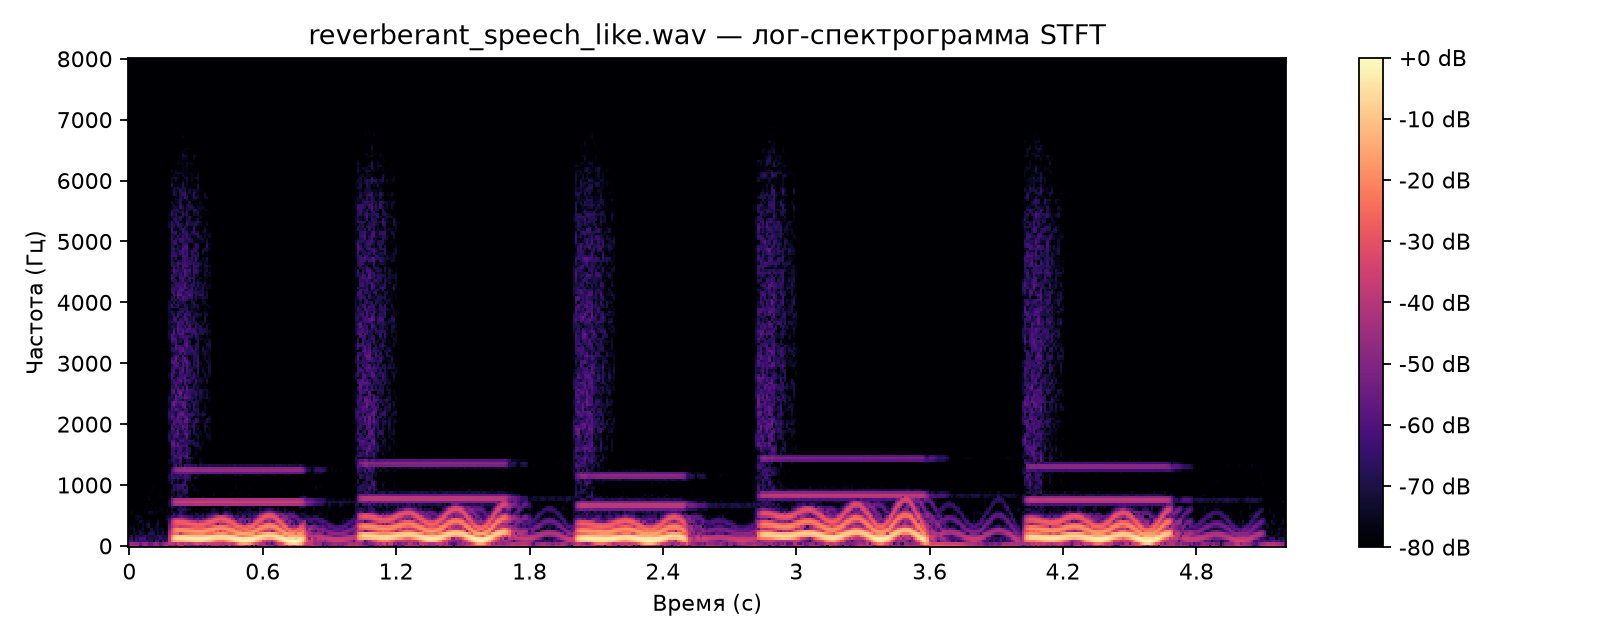

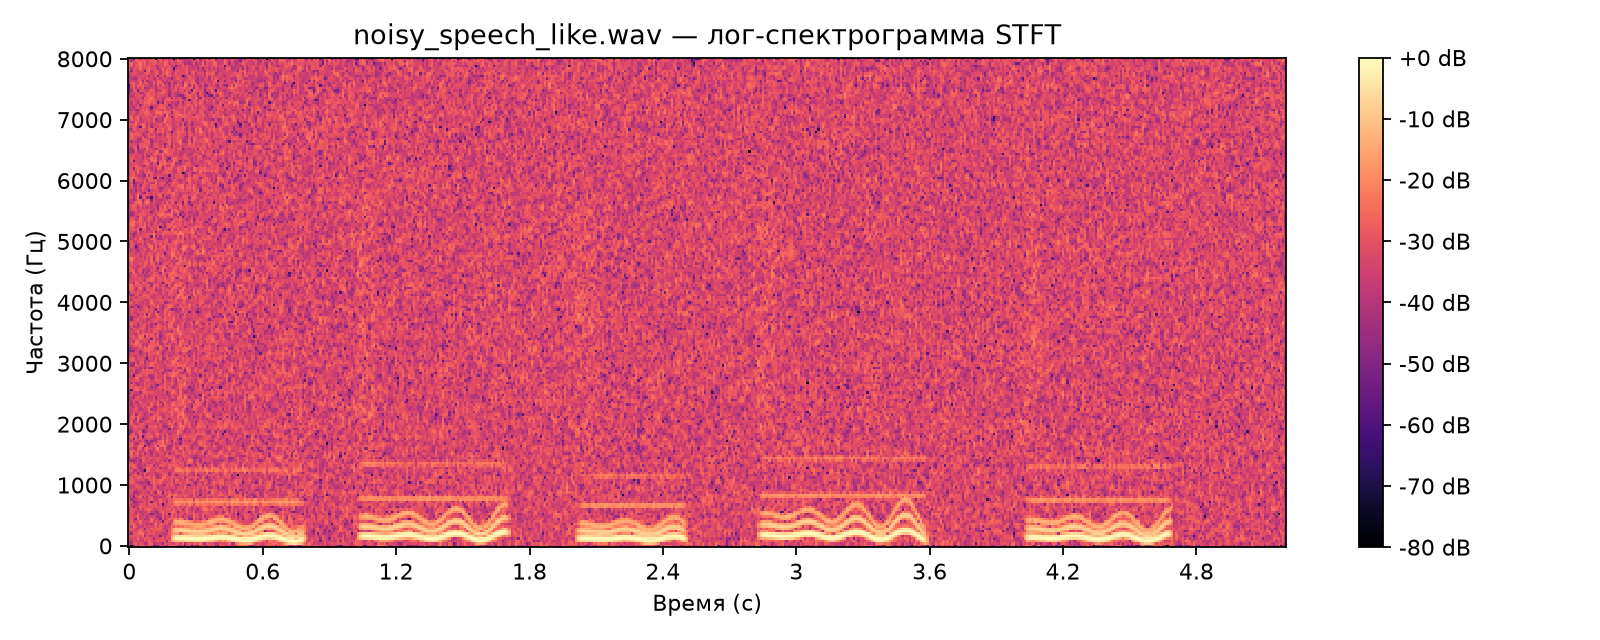

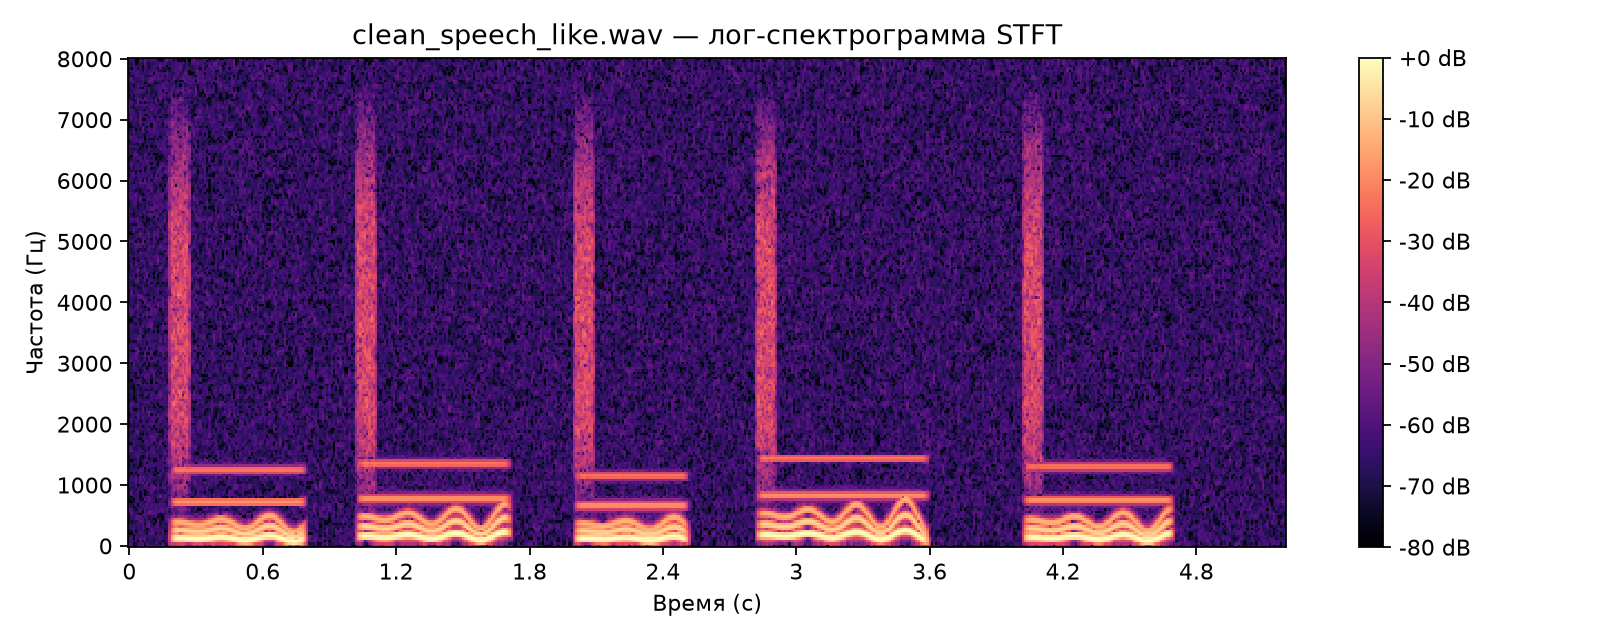

In [45]:
for spec_img in spec_imgs:
    display(Image(filename=spec_img))

**Вопросы:**

1. В каком файле больше всего широкополосной высокочастотной энергии?
2. Как реверберация меняет time-frequency паттерн?
3. Почему шум может вызывать замены или удаления в ASR?

1. В зашумленном. На оригинальный наслаивается широкополосный шум. На спектрограмме это очень хорошо видно
2. Реверб размазывает сигнал во времени. Энергия звука продолжается после окончания исходного события, появляются "хвосты". Резкие границы становятся менее четкими
3. Шум ухудшает различимость как для людей, так и для машин. Ухуджается различимость фонем, особенно согласных, особенно глухиз согласных. Ухудшается различимость границ слов/фонем. Форма спектра зашумляется и модели труднее вычленять нужное. Отсюда замены и пропуски: либо модель не уверена в выборе, либо банально не слышит

## Часть E 

In [46]:
log_mel_imgs = list(OUTPUTS_DIR.glob("*_log_mel.png"))

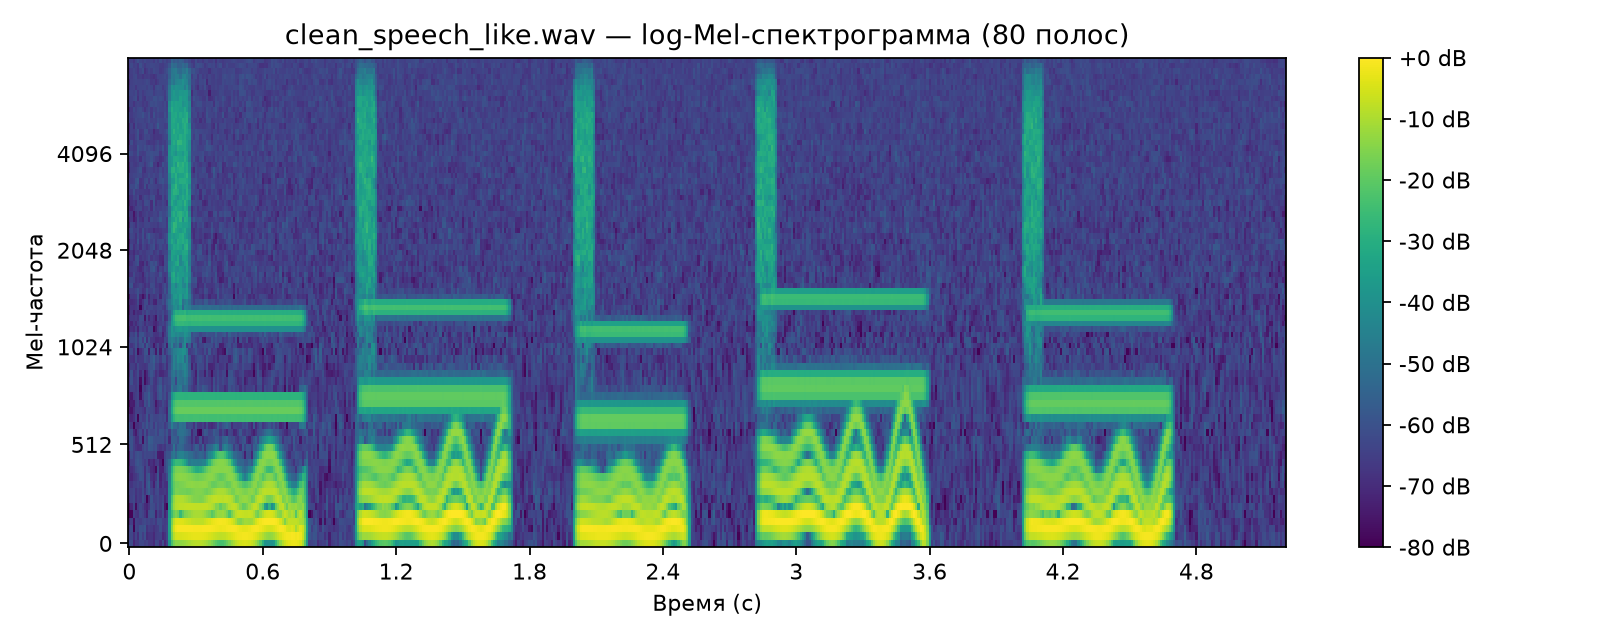

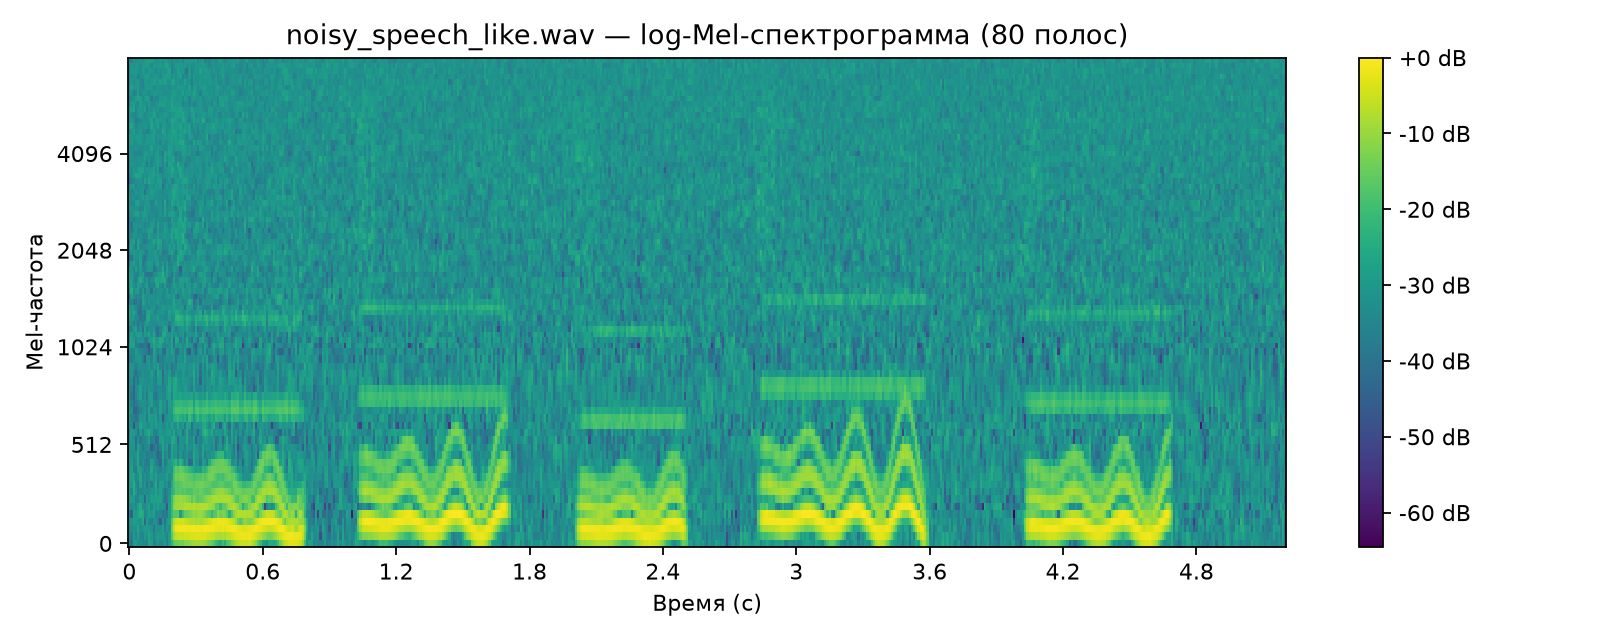

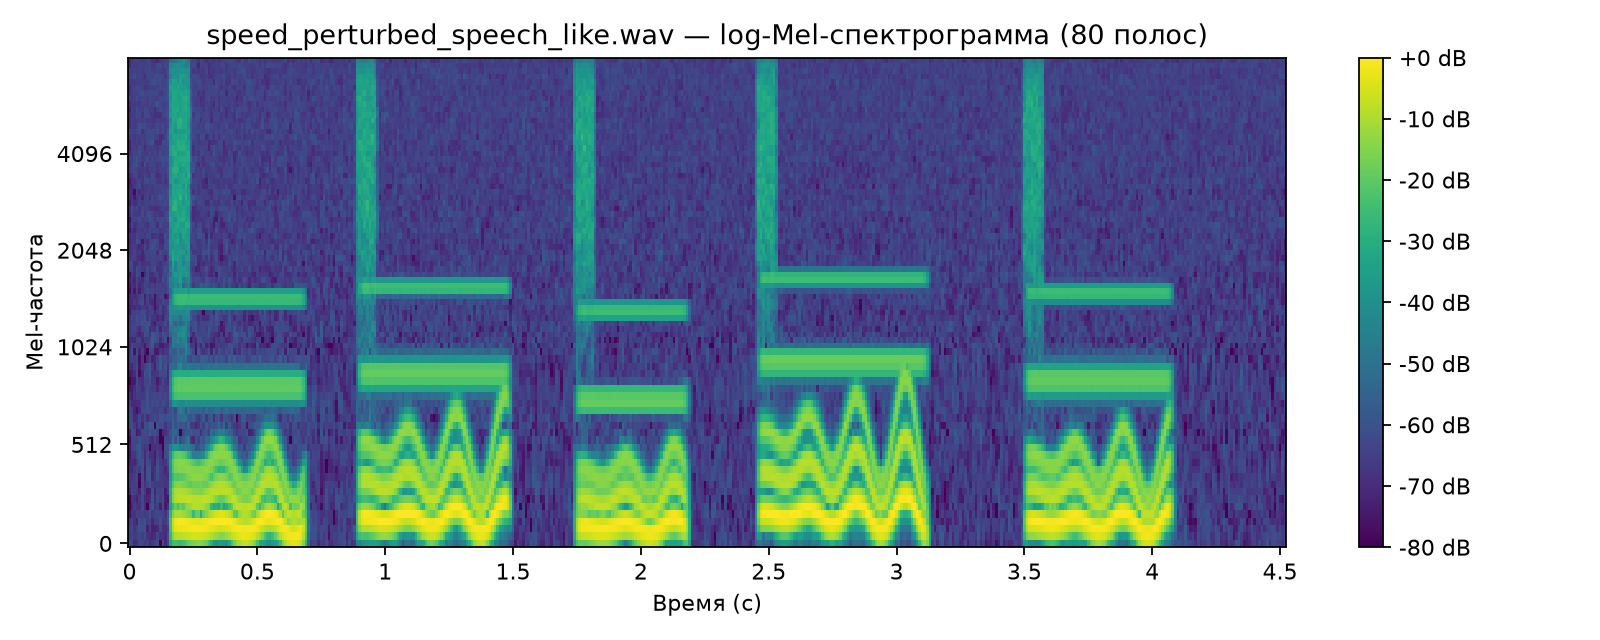

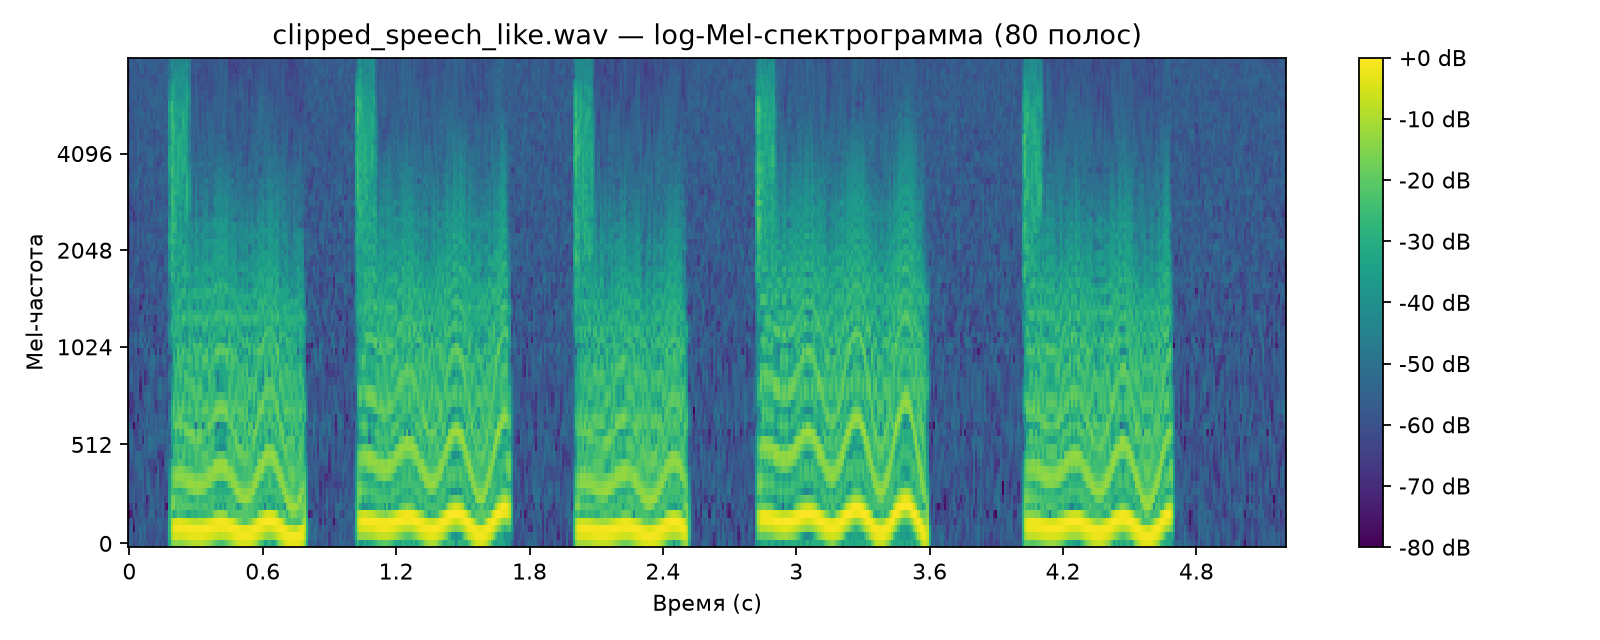

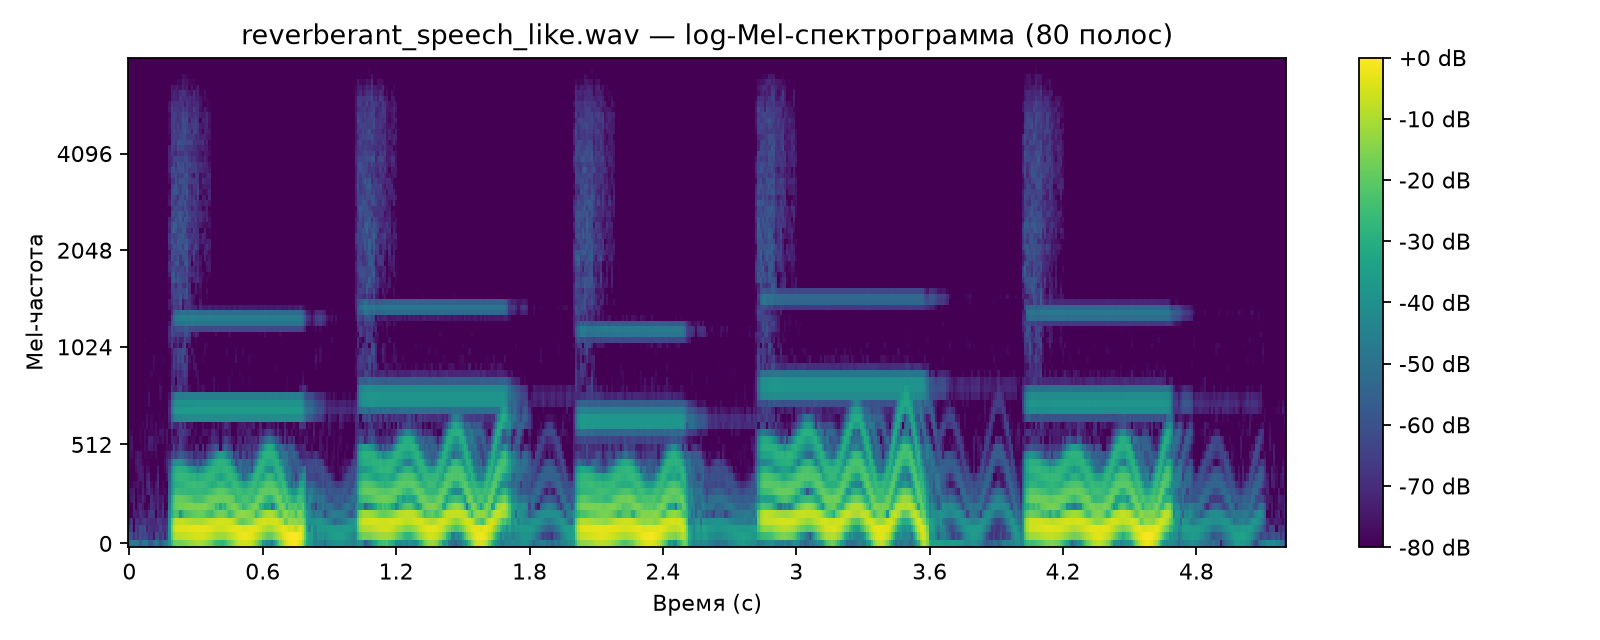

In [47]:
for log_mel_img in log_mel_imgs:
    display(Image(filename=log_mel_img))

**Вопросы:**

1. Какую информацию легче увидеть на log-Mel, чем на волновой форме?
2. Какая информация теряется или сжимается по сравнению с линейно-частотной STFT?
3. Почему логарифмические энергии полезны для речи?

1. На лог-мел шкале лучше видна спектральная структура речи. Лучше видны форманты, гласные, паузы и переходы между звуками
2. Лог-мел группирует спектр в мел-бины, сжимается разрешение на высоких частотах, которые для мел-шкалы менее актуальны, так как мел-банки ориентированы на частоты, содержащиеся в речи
3. Человеческое восприятие громкости логарифмическое. Также логарифм сжимает диапазон энергии и делает разрыв между сильно выраженными частотами и мало выраженными частотами меньше

## Часть F

In [48]:
log_mel_imgs = list(OUTPUTS_DIR.glob("*_mfcc.png"))

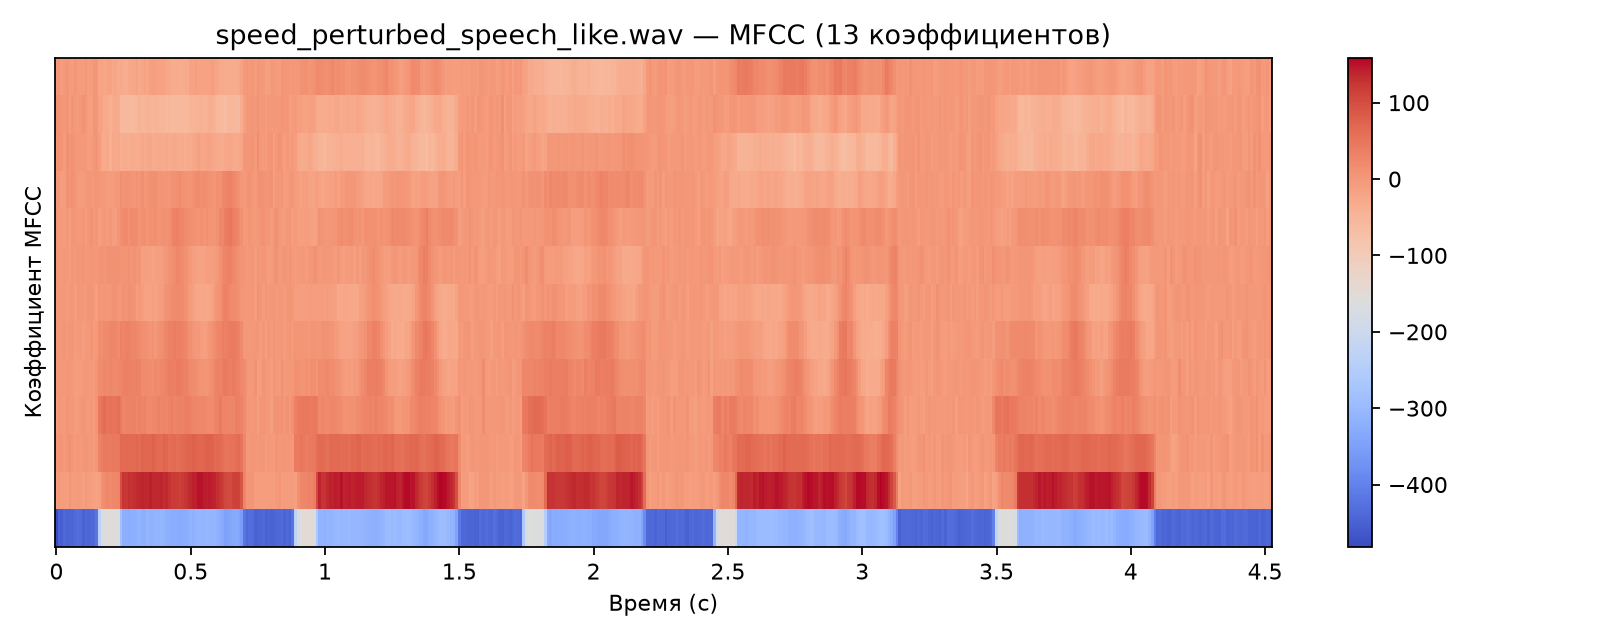

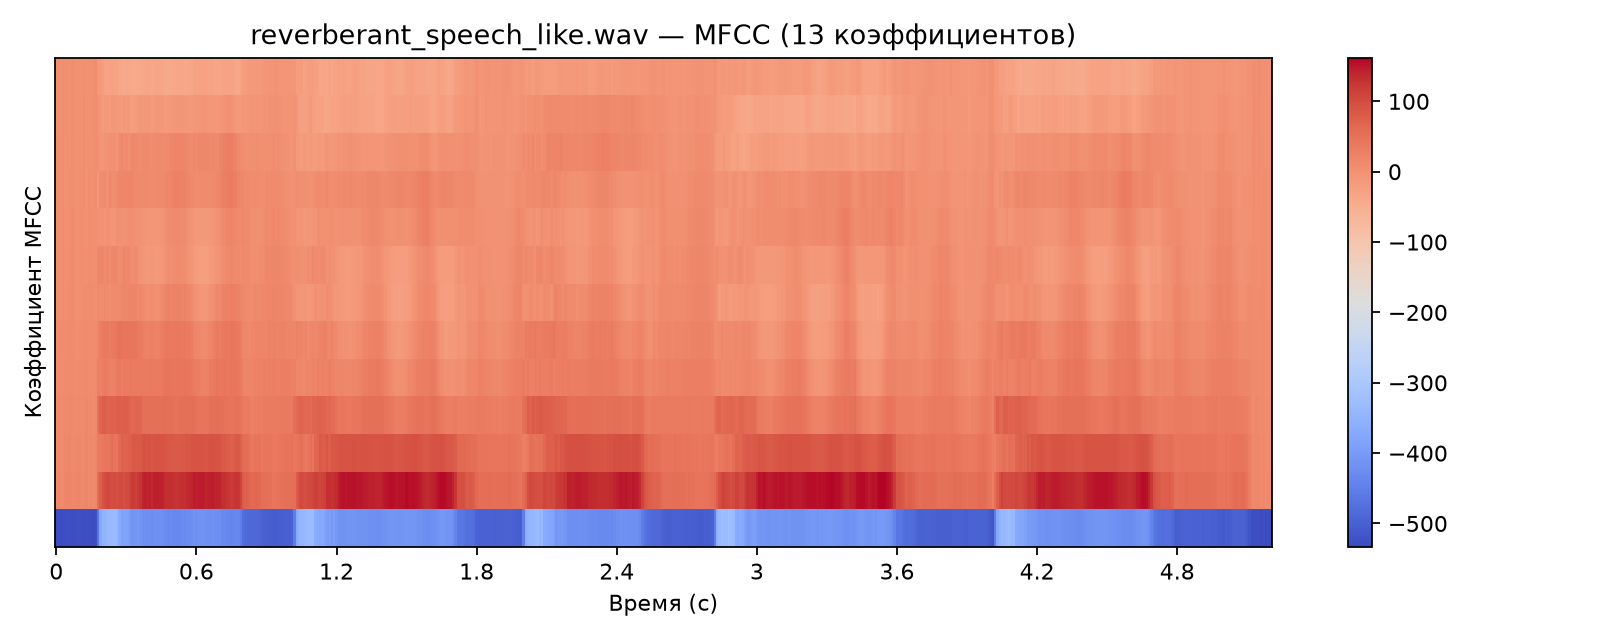

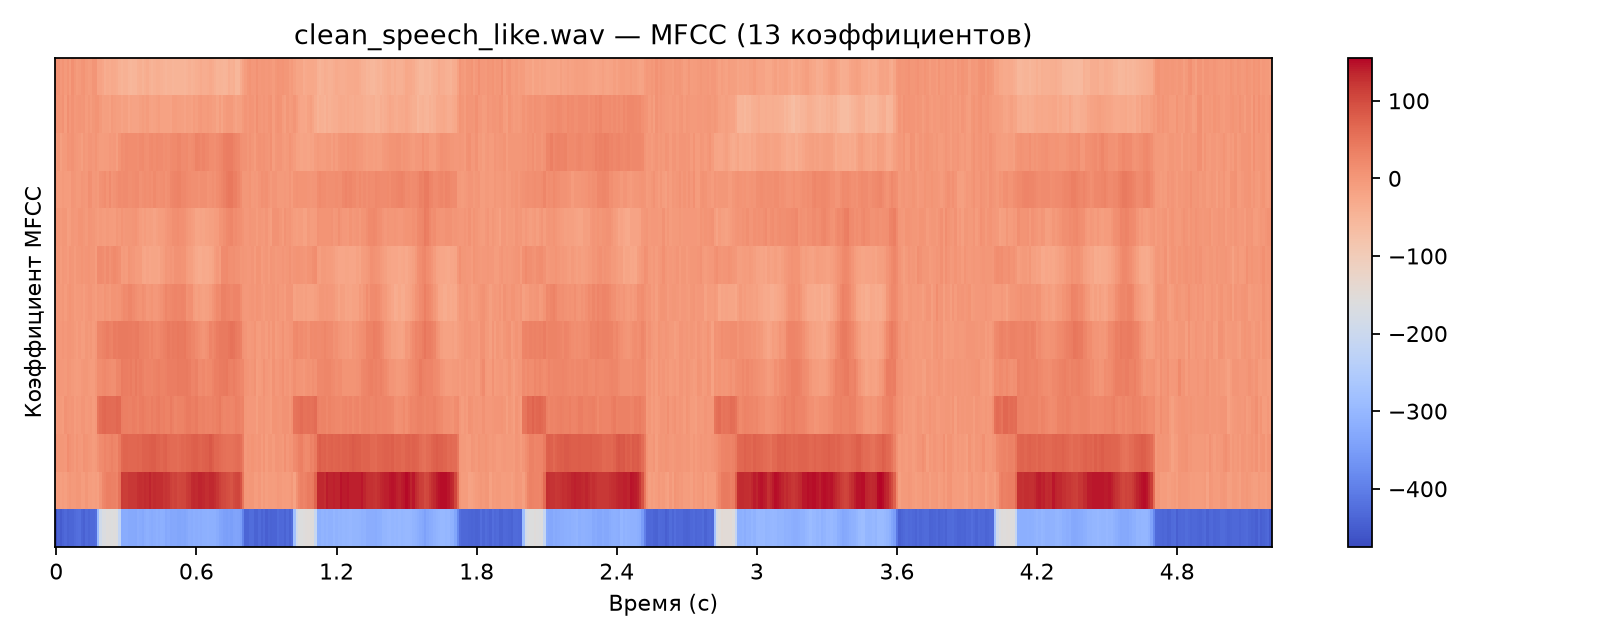

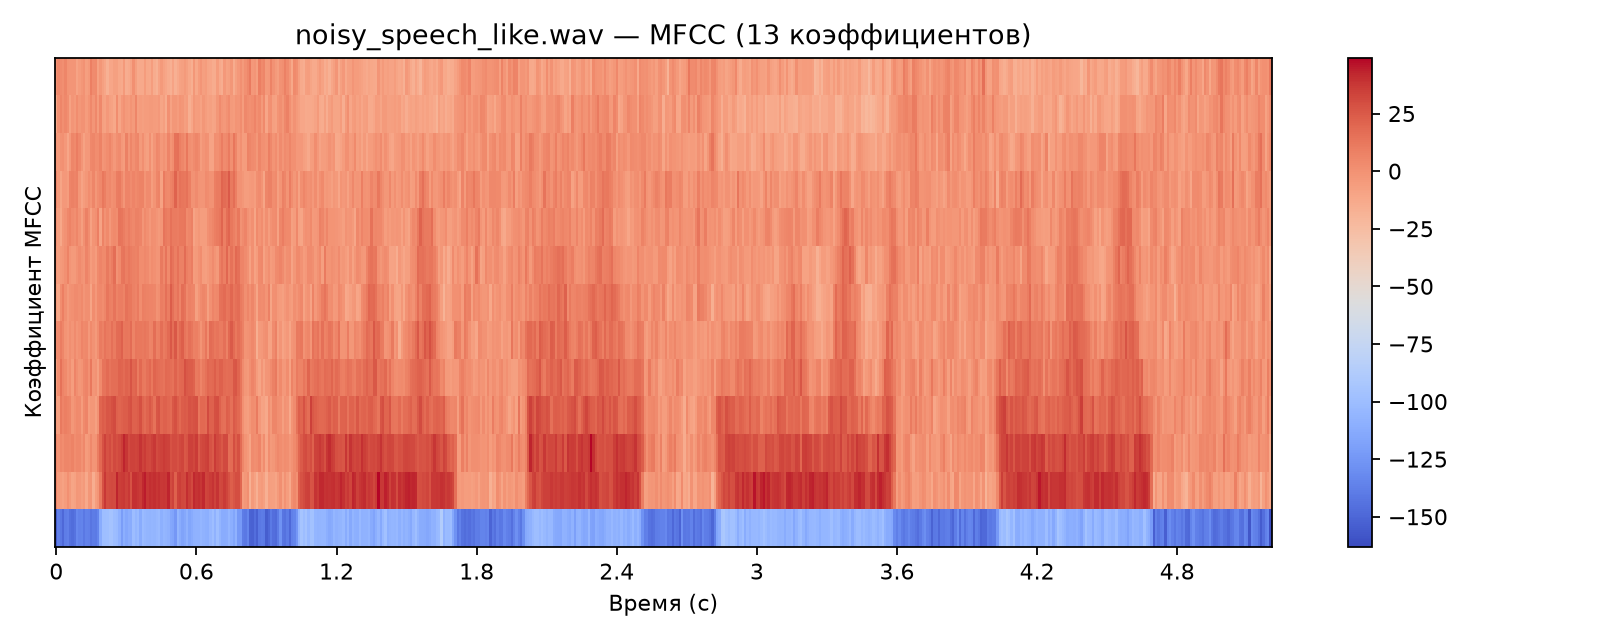

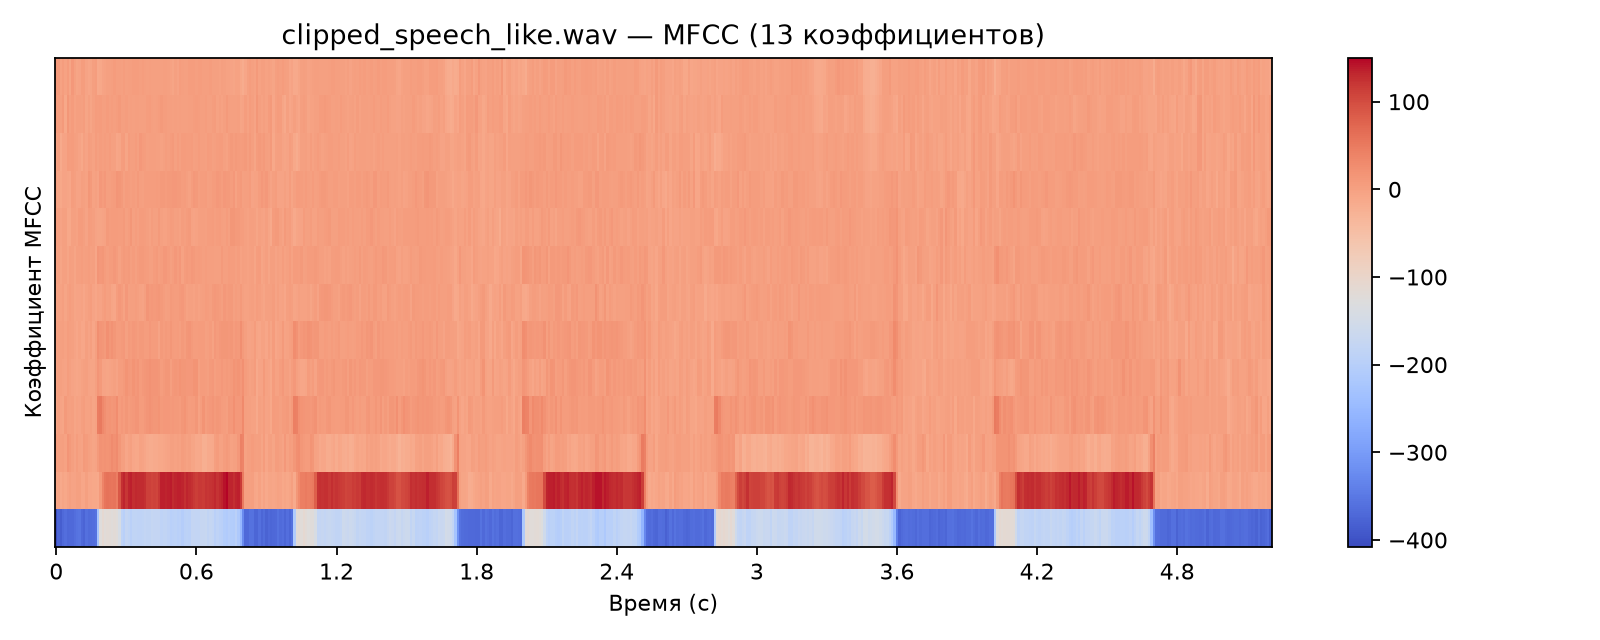

In [49]:
for log_mel_img in log_mel_imgs:
    display(Image(filename=log_mel_img))

**Вопросы:**

1. Чем визуально графики MFCC отличаются от log-Mel?
2. Почему компактное представление может быть полезным?
3. Почему современный нейросетевой ASR может предпочитать более богатые log-Mel признаки?

1. log-mel просто модифицирует stft. MFCC благодаря DCT разбивает сигнал на составляющие и создает новое представление, в котором первые коэффициенты описывают грубую, плавную форму спектральной огибающей, связанную с речевым трактом, а более высокие – более мелкие изменения спектральной формы
2. Можно обобщенно характеризовать речевой сигнал снижая значимость неважных для распознавания речи характеристик
3. Нейросетевой ASR может вычленять больше взаимосвязей и, как следствие, давать лучшие результаты. MFCC – компактное представление, обобщающее признаки и для выявления скрытых зависимостей может быть недостаточным

## Часть G

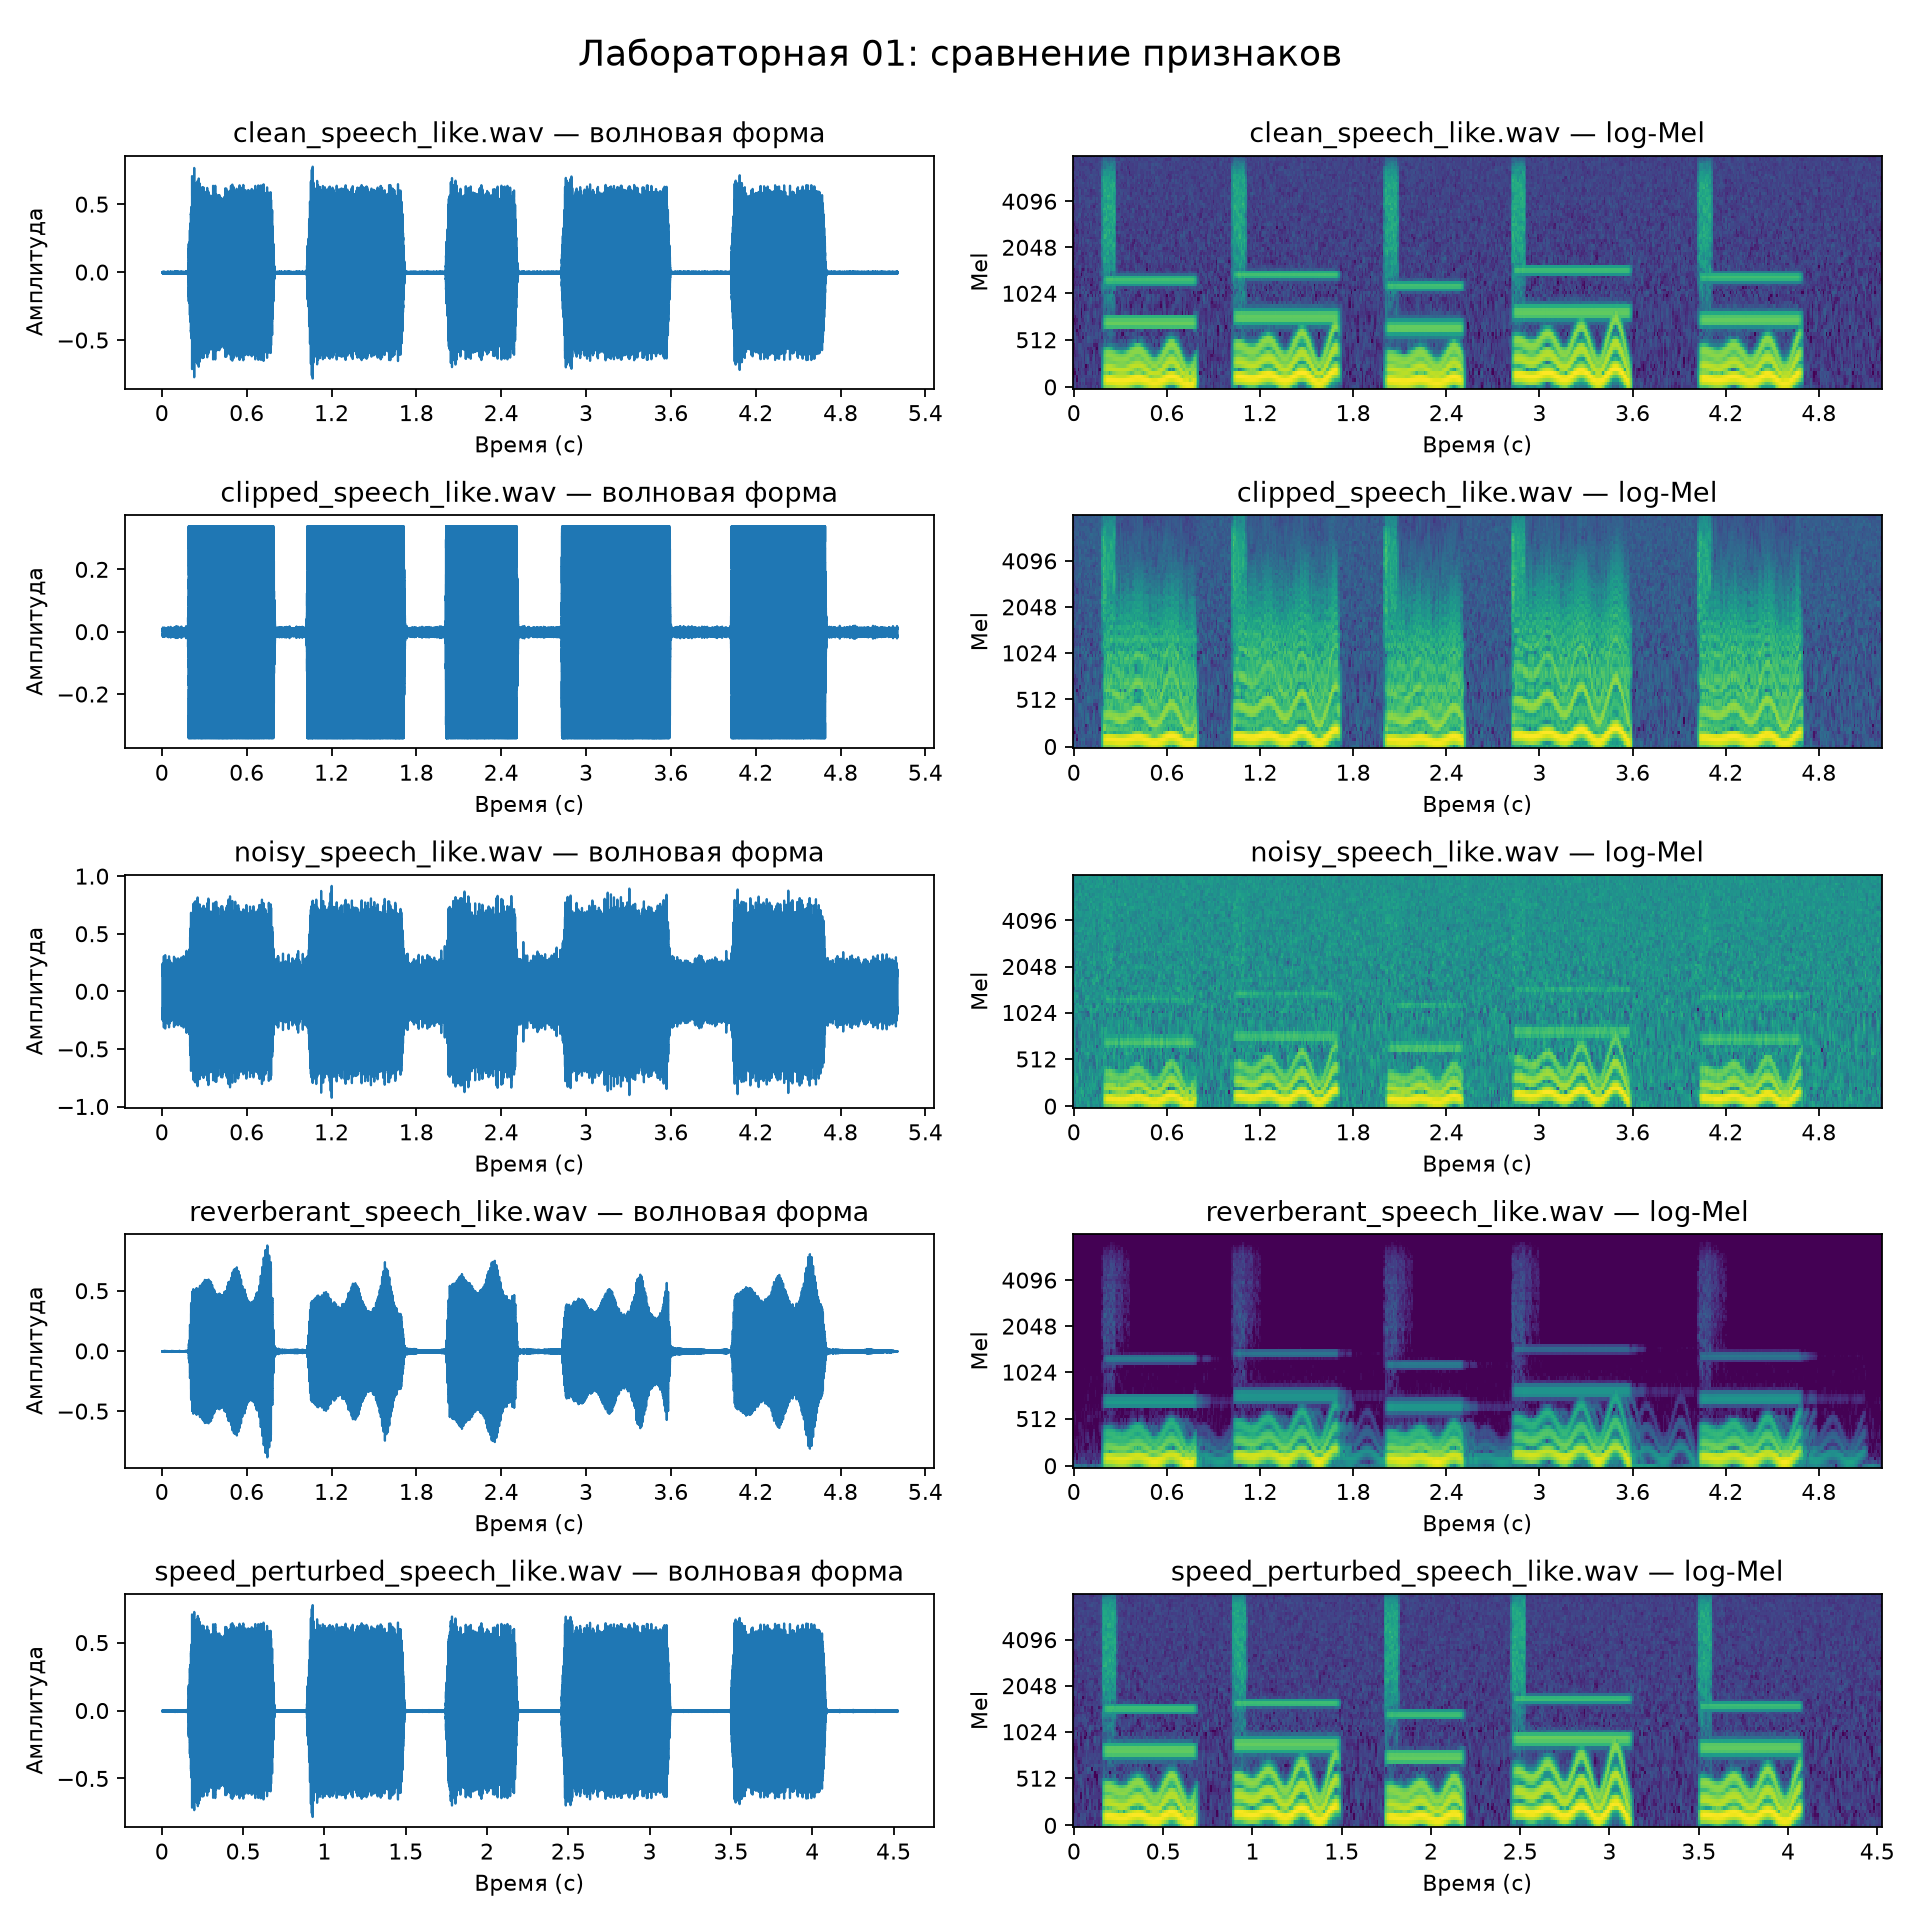

In [50]:
display(Image(filename=OUTPUTS_DIR / "feature_comparison_contact_sheet.png"))

In [56]:
answr = [
    [
        "Искажение",
        "Что изменилось в волновой форме?",
        "Что изменилось в спектрограмме/log-Mel?",
        "Возможный тип ошибки ASR"
    ],
    [
        "Clipping",
        "Срезались пики сигнала, форма стала более прямоугольной",
        "Стало больше энергии на высоких частотах",
        "Замена, удаление"
    ],
    [
        "Noise",
        "Шум появился и в речевых участках, и в паузах",
        "Появился шумовой фон по всему спектру, речь стала хуже выделяться",
        "Замена, вставка, плохое определение границ речи, галлюцинация"
    ],
    [
        "Reverberation",
        "После речевых участков появились хвосты",
        "Энергия растянулась по времени, соседние участки начали перекрываться",
        "Удаление, замена, неверная временная метка, плохое определение границ речи"
    ],
    [
        "Speed perturbation",
        "Сигнал стал короче, речевые участки сжались по времени",
        "Спектральная структура осталась похожей, но сжалась по времени",
        "Замена, удаление, неверная временная метка"
    ]
]

In [57]:
print(tabulate(answr))

------------------  -------------------------------------------------------  ---------------------------------------------------------------------  --------------------------------------------------------------------------
Искажение           Что изменилось в волновой форме?                         Что изменилось в спектрограмме/log-Mel?                                Возможный тип ошибки ASR
Clipping            Срезались пики сигнала, форма стала более прямоугольной  Стало больше энергии на высоких частотах                               Замена, удаление
Noise               Шум появился и в речевых участках, и в паузах            Появился шумовой фон по всему спектру, речь стала хуже выделяться      Замена, вставка, плохое определение границ речи, галлюцинация
Reverberation       После речевых участков появились хвосты                  Энергия растянулась по времени, соседние участки начали перекрываться  Удаление, замена, неверная временная метка, плохое определение границ речи
Speed 